# Bluestock Mutual Fund — Exploratory Data Analysis

**Notebook:** `03_eda_analysis.ipynb`  ·  **Stage:** Day 3 (EDA)

This notebook explores the cleaned Bluestock mutual-fund datasets across five themes. Each section
follows the same flow — **load → verify → analyse & visualise → insight** — and every chart is
exported to `reports/charts/`.

## Contents
1. [NAV Trend Analysis](#1.-NAV-Trend-Analysis) — daily NAV of 40 schemes (2022–2026)
2. [AUM Growth Analysis](#2.-AUM-Growth-Analysis) — assets under management by fund house
3. [SIP Inflow Trend Analysis](#3.-SIP-Inflow-Trend-Analysis) — monthly SIP inflows
4. [Category Inflow Analysis](#4.-Category-Inflow-Analysis) — net inflows by fund category
5. [Investor Demographics Analysis](#5.-Investor-Demographics-Analysis) — age & gender profile
6. [Geographic Distribution Analysis](#6.-Geographic-Distribution-Analysis) — SIP by state & T30/B30 reach
7. [Industry Folio Growth Analysis](#7.-Industry-Folio-Growth-Analysis) — total folios & CAGR
8. [NAV Return Correlation Analysis](#8.-NAV-Return-Correlation-Analysis) — return correlations (Markowitz input)
9. [Sector Allocation Analysis](#9.-Sector-Allocation-Analysis) — equity sector mix & concentration
10. [Key EDA Findings](#10.-Key-EDA-Findings) — consolidated insights, summary & data-quality log

## Datasets used
| Section | Source file | Grain |
|---|---|---|
| 1 | `data/processed/clean_nav_history.csv` | scheme × day |
| 2 | `data/raw/03_aum_by_fund_house.csv` | fund house × snapshot |
| 3 | `data/raw/04_monthly_sip_inflows.csv` | month |
| 4 | `data/raw/05_category_inflows.csv` | category × month |
| 5 | `data/processed/clean_investor_transactions.csv` | transaction |
| 6 | `data/processed/clean_investor_transactions.csv` | transaction |
| 7 | `data/raw/06_industry_folio_count.csv` | month |
| 8 | `clean_nav_history.csv` + `01_fund_master.csv` | scheme × day |
| 9 | `data/raw/09_portfolio_holdings.csv` + `01_fund_master.csv` | scheme × holding |

> **Reproduce:** Kernel → Restart & Run All. Static PNG export needs `kaleido` (`pip install kaleido`).

In [1]:
# === Setup: imports, paths, and shared styling (run once) ===
from pathlib import Path

import pandas as pd

# Plotly (interactive charts — sections 1 & 3)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Matplotlib / Seaborn (static charts — sections 2, 4 & 5)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

# --- Project paths (resolve repo root whether run from /notebooks or the repo root) ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CHARTS_DIR = PROJECT_ROOT / "reports" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Shared chart styling ---
pio.templates.default = "plotly_white"
sns.set_theme(style="whitegrid")
# seaborn's theme puts Arial first, but macOS Arial lacks the ₹ (U+20B9) glyph and renders it as a
# box. DejaVu Sans ships the glyph, so prefer it for every matplotlib chart in this notebook.
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"]

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Charts dir   : {CHARTS_DIR}")

Project root : /Users/dheerajreddy/bluestock_mf_capstone
Data dir     : /Users/dheerajreddy/bluestock_mf_capstone/data
Charts dir   : /Users/dheerajreddy/bluestock_mf_capstone/reports/charts


## 1. NAV Trend Analysis

Daily NAV history for all **40 AMFI schemes** over **2022–2026**: load, validate, and chart the
trends with shaded regions for the **2023 Bull Run** and the **2024 Market Correction**.

In [2]:
# Load the cleaned NAV dataset and parse the date column as datetime
NAV_PATH = DATA_DIR / "processed" / "clean_nav_history.csv"
nav = pd.read_csv(NAV_PATH, parse_dates=["date"])
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
# Verify row count, date range, and number of unique AMFI schemes
row_count = len(nav)
date_min, date_max = nav["date"].min(), nav["date"].max()
n_schemes = nav["amfi_code"].nunique()

print(f"Row count          : {row_count:,}")
print(f"Date range         : {date_min:%Y-%m-%d} → {date_max:%Y-%m-%d}")
print(f"Unique AMFI schemes: {n_schemes}")

assert nav["date"].dtype.kind == "M", "date column is not datetime"
assert nav[["amfi_code", "date", "nav"]].notna().all().all(), "unexpected nulls"

Row count          : 64,320
Date range         : 2022-01-03 → 2026-05-29
Unique AMFI schemes: 40


In [4]:
# Map AMFI codes to scheme names where available; fall back to the code otherwise
FUND_MASTER_PATH = DATA_DIR / "raw" / "01_fund_master.csv"
fund_master = pd.read_csv(FUND_MASTER_PATH, usecols=["amfi_code", "scheme_name"])
name_map = dict(zip(fund_master["amfi_code"], fund_master["scheme_name"]))

nav["scheme"] = nav["amfi_code"].map(lambda code: name_map.get(code, f"AMFI {code}"))

matched = nav["amfi_code"].map(lambda c: c in name_map).groupby(nav["amfi_code"]).first()
print(f"Schemes with a resolved name: {int(matched.sum())} / {n_schemes}")
nav[["amfi_code", "scheme"]].drop_duplicates().head()

Schemes with a resolved name: 40 / 40


,amfi_code,scheme
0,100016,HDFC Top 100 Fund - Regular Plan - Growth
1608,100025,HDFC Short Term Debt Fund - Regular - Growth
3216,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4824,101206,ABSL Frontline Equity Fund - Regular - Growth
6432,101207,ABSL Small Cap Fund - Regular - Growth


In [5]:
# Interactive line chart of daily NAV trends for all 40 schemes, with shaded market regimes
fig = px.line(
    nav, x="date", y="nav", color="scheme",
    title="Daily NAV Trends — 40 AMFI Schemes (2022–2026)",
    labels={"date": "Date", "nav": "Net Asset Value (₹)", "scheme": "Scheme"},
)
fig.update_traces(
    line=dict(width=1),
    hovertemplate="<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>NAV: ₹%{y:.2f}<extra></extra>",
)

# Shaded vertical regions for the two market regimes
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08,
              line_width=0, layer="below",
              annotation_text="2023 Bull Run", annotation_position="top left")
fig.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.08,
              line_width=0, layer="below",
              annotation_text="2024 Correction", annotation_position="top left")

fig.update_layout(
    hovermode="closest",
    legend=dict(title="Scheme", font=dict(size=9), itemwidth=30),
    height=650, margin=dict(l=60, r=40, t=70, b=60),
)
fig.show()

# Export to PNG (requires kaleido)
nav_chart_path = CHARTS_DIR / "nav_trend.png"
pio.write_image(fig, nav_chart_path, width=1400, height=700, scale=2)
print(f"Saved chart → {nav_chart_path.relative_to(PROJECT_ROOT)}")

Saved chart → reports/charts/nav_trend.png


### Insight — NAV Trends

**Overall growth.** Almost every scheme trends upward across 2022–2026; the median scheme roughly
doubles (~**+97%**), confirming a broad-based bull market with short drawdowns rather than sustained
decline.

**Variation across schemes.** Full-period returns span **~+5% to ~+249%** — the strongest schemes
grew nearly 50× faster than the weakest. Scheme selection mattered enormously even in a favourable
market.

**2023 rally (shaded green).** Median scheme gain ~**+15%** (best ~+59%), with the widest
leader-vs-laggard gap of the period; a few schemes still finished 2023 down (~−21%), so the rally
was selective.

**2024 correction (shaded red).** Better read as a **mid-cycle wobble than a crash** — median still
~**+6%** over the half-year, but ~28% of schemes turned negative (worst ~−15%) before NAVs resumed
their climb.

## 2. AUM Growth Analysis

**Assets Under Management** by fund house over **2022–2025**. The data holds point-in-time (stock)
snapshots, so we take the **latest snapshot within each year**, rank houses by most recent AUM, and
chart year-on-year growth — highlighting **SBI Mutual Fund's** lead.

In [6]:
# Load the AUM dataset and parse the date column as datetime
AUM_PATH = DATA_DIR / "raw" / "03_aum_by_fund_house.csv"
aum = pd.read_csv(AUM_PATH, parse_dates=["date"])
aum = aum.sort_values(["fund_house", "date"]).reset_index(drop=True)

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
1,2022-09-30,Aditya Birla Sun Life MF,2.85,285000,199
2,2023-03-31,Aditya Birla Sun Life MF,2.75,275000,199
3,2023-09-30,Aditya Birla Sun Life MF,3.08,308000,199
4,2024-03-31,Aditya Birla Sun Life MF,3.40,340000,199


In [7]:
# Verify row count, date range, and unique fund houses
print(f"Row count        : {len(aum):,}")
print(f"Date range       : {aum['date'].min():%Y-%m-%d} → {aum['date'].max():%Y-%m-%d}")
print(f"Snapshot dates   : {aum['date'].dt.strftime('%Y-%m-%d').nunique()} "
      f"({', '.join(sorted(aum['date'].dt.strftime('%Y-%m-%d').unique()))})")
print(f"Unique fund houses: {aum['fund_house'].nunique()}")

assert aum["date"].dtype.kind == "M", "date column is not datetime"
assert aum[["fund_house", "aum_lakh_crore"]].notna().all().all(), "unexpected nulls"

Row count        : 90
Date range       : 2022-03-31 → 2025-12-31
Snapshot dates   : 9 (2022-03-31, 2022-09-30, 2023-03-31, 2023-09-30, 2024-03-31, 2024-09-30, 2024-12-31, 2025-03-31, 2025-12-31)
Unique fund houses: 10


In [8]:
# Aggregate annual AUM by fund house for 2022–2025.
# AUM is a stock (point-in-time) value, so take the LATEST snapshot within each year rather than
# summing the half-yearly snapshots.
aum["year"] = aum["date"].dt.year
aum = aum[aum["year"].between(2022, 2025)]

latest_idx = aum.groupby(["fund_house", "year"])["date"].idxmax()
annual_aum = aum.loc[latest_idx].pivot(index="fund_house", columns="year", values="aum_lakh_crore")

# Sort fund houses by latest available AUM (descending)
latest_year = annual_aum.columns.max()
house_order = annual_aum[latest_year].sort_values(ascending=False).index
annual_aum = annual_aum.loc[house_order]

print(f"Annual AUM (₹ lakh crore), sorted by {latest_year}:")
annual_aum.round(2)

Annual AUM (₹ lakh crore), sorted by 2025:


year,2022,2023,2024,2025
fund_house,,,,
SBI Mutual Fund,6.30,8.45,11.14,12.50
ICICI Prudential MF,4.88,5.90,8.74,10.74
HDFC Mutual Fund,4.45,5.35,7.87,9.30
Nippon India MF,2.78,3.40,5.70,7.00
Kotak Mahindra MF,2.72,3.25,4.89,5.80
Aditya Birla Sun Life MF,2.85,3.08,3.84,4.60
UTI Mutual Fund,2.32,2.65,3.52,4.10
Axis Mutual Fund,2.40,2.60,3.00,3.50
Mirae Asset MF,1.08,1.42,2.10,2.90


Saved chart → reports/charts/aum_growth.png


/tmp/claude-501/ipykernel_5149/2896762740.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


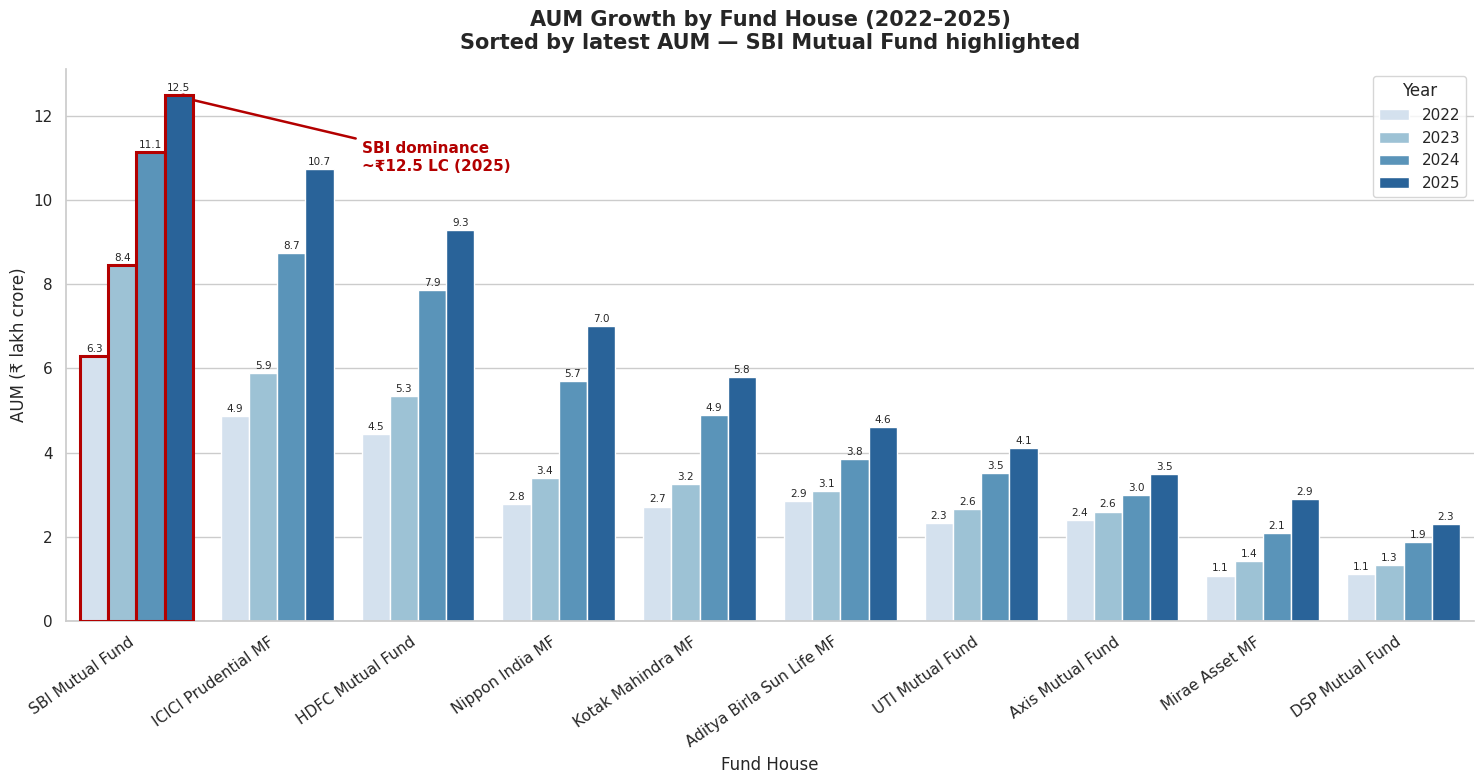

In [9]:
# Grouped bar chart: AUM by fund house and year, SBI highlighted, exported to PNG
plot_df = (
    annual_aum.loc[house_order]
    .reset_index()
    .melt(id_vars="fund_house", var_name="year", value_name="aum_lakh_crore")
)
plot_df["year"] = plot_df["year"].astype(str)

fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(data=plot_df, x="fund_house", y="aum_lakh_crore", hue="year",
            palette="Blues", edgecolor="white", ax=ax)

# Highlight SBI Mutual Fund: outline its bars and annotate the ~12.5 LC dominance
SBI = "SBI Mutual Fund"
if SBI in house_order:
    sbi_pos = list(house_order).index(SBI)
    n_years = plot_df["year"].nunique()
    for grp in range(n_years):  # bars for one x-category sit at sbi_pos within each hue group
        patch = ax.patches[grp * len(house_order) + sbi_pos]
        patch.set_edgecolor("#b30000"); patch.set_linewidth(2.2); patch.set_zorder(5)

    sbi_2025 = annual_aum.loc[SBI, latest_year]
    ax.annotate(
        f"SBI dominance\n~₹{sbi_2025:.1f} LC ({latest_year})",
        xy=(sbi_pos + 0.25, sbi_2025), xytext=(sbi_pos + 1.6, sbi_2025 - 1.8),
        ha="left", fontsize=11, fontweight="bold", color="#b30000",
        arrowprops=dict(arrowstyle="->", color="#b30000", lw=1.8),
    )

for container in ax.containers:  # value labels for readability
    ax.bar_label(container, fmt="%.1f", fontsize=7.5, padding=1.5)

ax.set_title("AUM Growth by Fund House (2022–2025)\n"
             "Sorted by latest AUM — SBI Mutual Fund highlighted",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Fund House", fontsize=12)
ax.set_ylabel("AUM (₹ lakh crore)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.legend(title="Year", frameon=True, loc="upper right")
sns.despine(); fig.tight_layout()

aum_chart_path = CHARTS_DIR / "aum_growth.png"
fig.savefig(aum_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {aum_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

### Insight — AUM Growth

**Largest houses.** As of 2025, **SBI (~₹12.5 LC)** leads, then **ICICI Prudential (~₹10.7 LC)** and
**HDFC (~₹9.3 LC)**; Nippon India (~₹7.0 LC) and Kotak (~₹5.8 LC) complete the top five. Mirae and
DSP remain under ₹3 LC.

**Concentration.** The **top 3 hold ~52%** of the ₹62.7 LC tracked AUM; SBI alone ≈ **20%**. The
scale gap between leaders and the rest is wide and widening.

**Growth 2022–2025.** A rising tide — every house grew. SBI roughly **doubled (~+98%)**, ICICI more
than doubled, and Nippon/Mirae grew fastest off smaller bases. The steepest jump was **2024**.

**SBI vs. competitors.** SBI is **pulling away** — ~₹1.8 LC ahead of ICICI (a wider lead than in
2022), and its 2025 AUM exceeds the combined total of the four smallest houses.

## 3. SIP Inflow Trend Analysis

Monthly **SIP inflows** over **Jan 2022 – Dec 2025**: verify the data, resolve the **12 missing
values** flagged on Day 1, and chart the trend with per-month markers, a 3-month moving average,
and the all-time-high annotation.

In [10]:
# Load the monthly SIP inflow dataset and parse the month column as datetime
SIP_PATH = DATA_DIR / "raw" / "04_monthly_sip_inflows.csv"
sip = pd.read_csv(SIP_PATH)
sip["date"] = pd.to_datetime(sip["month"], format="%Y-%m")  # month-start timestamps
sip = sip.sort_values("date").reset_index(drop=True)

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct,date
0,2022-01,11517,4.91,9.10,4.80,NaN,2022-01-01
1,2022-02,11438,4.93,8.20,4.85,NaN,2022-02-01
2,2022-03,12328,5.09,10.50,5.01,NaN,2022-03-01
3,2022-04,11863,5.48,9.52,5.12,NaN,2022-04-01
4,2022-05,12286,5.55,8.10,5.15,NaN,2022-05-01


In [11]:
# Verify row count, date range, and missing values
print(f"Row count   : {len(sip):,}")
print(f"Date range  : {sip['date'].min():%Y-%m} → {sip['date'].max():%Y-%m}")
print(f"Total missing values: {int(sip.isna().sum().sum())}")
print("\nMissing values per column:")
print(sip.isna().sum().to_string())

# Investigate the 12 missing values flagged during Day 1 profiling
missing_rows = sip[sip.isna().any(axis=1)]
print(f"\nRows containing a missing value: {len(missing_rows)}")
print("Columns affected :", [c for c in sip.columns if sip[c].isna().any()])
print("Months affected  :", missing_rows["month"].tolist())

Row count   : 48
Date range  : 2022-01 → 2025-12
Total missing values: 12

Missing values per column:
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
date                          0

Rows containing a missing value: 12
Columns affected : ['yoy_growth_pct']
Months affected  : ['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12']


### Missing-value investigation & handling methodology

**Day 1 finding.** Profiling flagged **12 missing values**. The check above localises all 12 to one
column — **`yoy_growth_pct`** — and all fall in the **2022** rows (Jan–Dec 2022).

**Root cause — structural, not an error.** Year-on-year growth compares a month to the *same month
one year earlier*. The series starts in **Jan 2022**, so there is no 2021 baseline; YoY is genuinely
**Not Applicable** for the first 12 months, not lost or corrupted.

**Methodology.**
- We **do not impute** the 2022 values — filling them would fabricate a meaningless growth rate.
- We **recompute YoY from the raw inflow series**, which correctly populates 2023–2025 and
  legitimately leaves 2022 as `NaN`.
- The charted column **`sip_inflow_crore` has zero missing values**, so the chart is unaffected.

In [12]:
# Handle missing values + compute the rolling 3-month moving average.
# yoy_growth_pct is structurally absent for 2022 (no 2021 baseline), so we do NOT impute it;
# we recompute it where a true 12-month-prior value exists and let 2022 stay NaN (Not Applicable).
sip = sip.sort_values("date").reset_index(drop=True)
sip["yoy_growth_pct"] = (sip["sip_inflow_crore"] / sip["sip_inflow_crore"].shift(12) - 1) * 100

# The charted series (sip_inflow_crore) is complete — no imputation needed there.
sip["sip_ma3"] = sip["sip_inflow_crore"].rolling(window=3, min_periods=1).mean()

print("Remaining NaNs in yoy_growth_pct (expected = 12, the 2022 baseline year):",
      int(sip["yoy_growth_pct"].isna().sum()))
print("NaNs in charted column sip_inflow_crore:", int(sip["sip_inflow_crore"].isna().sum()))
sip[["month", "sip_inflow_crore", "sip_ma3", "yoy_growth_pct"]].head(14).round(1)

Remaining NaNs in yoy_growth_pct (expected = 12, the 2022 baseline year): 12
NaNs in charted column sip_inflow_crore: 0


,month,sip_inflow_crore,sip_ma3,yoy_growth_pct
0,2022-01,11517,11517.0,NaN
1,2022-02,11438,11477.5,NaN
2,2022-03,12328,11761.0,NaN
3,2022-04,11863,11876.3,NaN
4,2022-05,12286,12159.0,NaN
5,2022-06,12276,12141.7,NaN
6,2022-07,12140,12234.0,NaN
7,2022-08,12694,12370.0,NaN
8,2022-09,12976,12603.3,NaN
9,2022-10,13040,12903.3,NaN


In [13]:
# Interactive time-series of monthly SIP inflows (Jan 2022 – Dec 2025)
fig = go.Figure()

# Monthly inflows with markers on every observation
fig.add_trace(go.Scatter(
    x=sip["date"], y=sip["sip_inflow_crore"], mode="lines+markers", name="Monthly SIP inflow",
    line=dict(color="#1f77b4", width=2), marker=dict(size=6),
    hovertemplate="%{x|%b %Y}<br>SIP inflow: ₹%{y:,.0f} Cr<extra></extra>",
))

# Rolling 3-month moving-average trendline
fig.add_trace(go.Scatter(
    x=sip["date"], y=sip["sip_ma3"], mode="lines", name="3-month moving average",
    line=dict(color="#ff7f0e", width=2.5, dash="dash"),
    hovertemplate="%{x|%b %Y}<br>3M avg: ₹%{y:,.0f} Cr<extra></extra>",
))

# Annotate the all-time high (Dec 2025 ≈ ₹31,002 Cr)
peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
peak_date = peak_row["date"].strftime("%Y-%m-%d")   # str so Plotly can serialize it
peak_label = peak_row["date"].strftime("%b %Y")
peak_val = int(peak_row["sip_inflow_crore"])
fig.add_trace(go.Scatter(
    x=[peak_date], y=[peak_val], mode="markers", name="All-time high",
    marker=dict(color="#d62728", size=12, symbol="star"),
    hovertemplate=f"All-time high<br>{peak_label}: ₹%{{y:,.0f}} Cr<extra></extra>",
))
fig.add_annotation(
    x=peak_date, y=peak_val, text=f"All-time high<br>{peak_label}: ₹{peak_val:,.0f} Cr",
    showarrow=True, arrowhead=2, arrowcolor="#d62728", ax=-70, ay=-55,
    font=dict(color="#d62728", size=12, family="Arial Black"),
    bgcolor="rgba(255,255,255,0.85)", bordercolor="#d62728", borderwidth=1,
)

fig.update_layout(
    title="Monthly SIP Inflows in India (Jan 2022 – Dec 2025)",
    xaxis_title="Month", yaxis_title="SIP Inflow (₹ crore)",
    hovermode="x unified", height=600,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    margin=dict(l=70, r=40, t=80, b=60),
)
fig.update_yaxes(tickprefix="₹", tickformat=",.0f", ticksuffix=" Cr")
fig.update_xaxes(dtick="M3", tickformat="%b\n%Y")
fig.show()

# Export to PNG
sip_chart_path = CHARTS_DIR / "sip_inflow_trend.png"
pio.write_image(fig, sip_chart_path, width=1400, height=650, scale=2)
print(f"Saved chart → {sip_chart_path.relative_to(PROJECT_ROOT)}")

Saved chart → reports/charts/sip_inflow_trend.png


### Insight — SIP Inflows

**Growth.** Monthly inflows rose from **₹11,517 Cr (Jan 2022) to ₹31,002 Cr (Dec 2025), ~+169%**.
Annual averages climbed steadily (~₹12.5k → ₹15.4k → ₹22.5k → ₹28.0k Cr), with only shallow
month-on-month dips — SIP behaves as a sticky savings habit, not a market-timed flow.

**Phases.** Flat in 2022, picking up through 2023 and **accelerating sharply in 2024** (~+46% YoY),
then moderating in 2025 as inflows crossed ₹30k Cr.

**Peak.** The **all-time high ₹31,002 Cr is Dec 2025** — also the series maximum, so the trend ends
at its peak. Monthly contributions are now ~**2.7×** their early-2022 level.

**Retail participation.** Record, sustained inflows signal deepening retail participation; this
steady domestic flow kept rising through the 2024 correction and underpins the AUM growth in §2.

## 4. Category Inflow Analysis

Net inflows by **fund category**: verify, pivot to a category × month matrix, and visualise as a
diverging heatmap plus a ranked cumulative-inflow bar chart.

> **Coverage note:** this file spans **Apr 2024 – Mar 2025 (12 months)**, not the full 2022–2025
> horizon, and contains **no negative inflows**. Insights are scoped strictly to what's present.

In [14]:
# Load the category inflow dataset and parse the month column as datetime
CAT_PATH = DATA_DIR / "raw" / "05_category_inflows.csv"
cat = pd.read_csv(CAT_PATH)
cat["date"] = pd.to_datetime(cat["month"], format="%Y-%m")
cat = cat.sort_values(["category", "date"]).reset_index(drop=True)

cat.head()

,month,category,net_inflow_crore,date
0,2024-04,ELSS,466.0,2024-04-01
1,2024-05,ELSS,553.0,2024-05-01
2,2024-06,ELSS,472.0,2024-06-01
3,2024-07,ELSS,471.0,2024-07-01
4,2024-08,ELSS,499.0,2024-08-01


In [15]:
# Verify row count, date range, unique categories, missing values
print(f"Row count        : {len(cat):,}")
print(f"Date range       : {cat['date'].min():%Y-%m} → {cat['date'].max():%Y-%m} "
      f"({cat['month'].nunique()} months)")
print(f"Unique categories: {cat['category'].nunique()}")
print(f"  {sorted(cat['category'].unique())}")
print(f"Missing values   : {int(cat.isna().sum().sum())}")
print(f"Negative inflows : {int((cat['net_inflow_crore'] < 0).sum())} "
      f"(min cell = ₹{cat['net_inflow_crore'].min():,.0f} Cr)")

assert cat["date"].dtype.kind == "M", "date column is not datetime"
assert cat["net_inflow_crore"].notna().all(), "unexpected nulls in net_inflow_crore"

Row count        : 144
Date range       : 2024-04 → 2025-03 (12 months)
Unique categories: 12
  ['ELSS', 'Flexi Cap', 'Gilt', 'Hybrid', 'Large & Mid Cap', 'Large Cap', 'Liquid', 'Mid Cap', 'Sectoral/Thematic', 'Short Duration', 'Small Cap', 'Value/Contra']
Missing values   : 0
Negative inflows : 0 (min cell = ₹437 Cr)


In [16]:
# Pivot table: rows = category, columns = month, values = net inflow (crore)
pivot = cat.pivot_table(index="category", columns="date", values="net_inflow_crore", aggfunc="sum")
print(f"Pivot shape: {pivot.shape[0]} categories x {pivot.shape[1]} months")
pivot.round(0)

Pivot shape: 12 categories x 12 months


date,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


Saved chart → reports/charts/category_inflow_heatmap.png

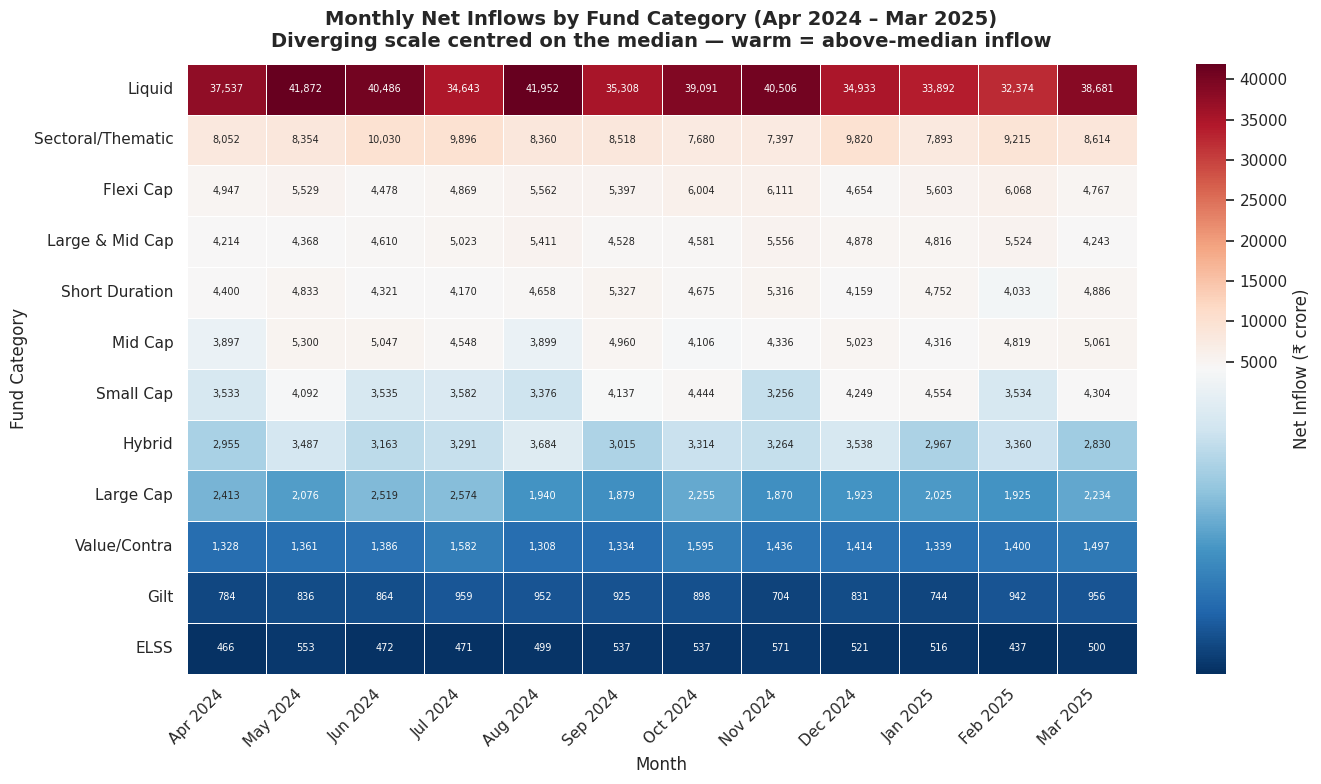

In [17]:
# Diverging heatmap of net inflows (category x month)
# Order rows by cumulative inflow (largest at top) for a readable layout
row_order = cat.groupby("category")["net_inflow_crore"].sum().sort_values(ascending=False).index
heat = pivot.loc[row_order]
heat.columns = [pd.Timestamp(c).strftime("%b %Y") for c in heat.columns]

# This dataset has NO outflows (all values > 0), so a literal 0-centred scale would be one-sided;
# we centre on the dataset MEDIAN so strong inflows (warm) separate from modest inflows (cool).
center = float(cat["net_inflow_crore"].median())
norm = TwoSlopeNorm(vmin=heat.values.min(), vcenter=center, vmax=heat.values.max())

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heat, cmap="RdBu_r", norm=norm, annot=True, fmt=",.0f", annot_kws={"size": 7},
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Net Inflow (₹ crore)"}, ax=ax)
ax.set_title("Monthly Net Inflows by Fund Category (Apr 2024 – Mar 2025)\n"
             "Diverging scale centred on the median — warm = above-median inflow",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Fund Category", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()

heat_chart_path = CHARTS_DIR / "category_inflow_heatmap.png"
fig.savefig(heat_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {heat_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

Saved chart → reports/charts/category_cumulative_inflow.png


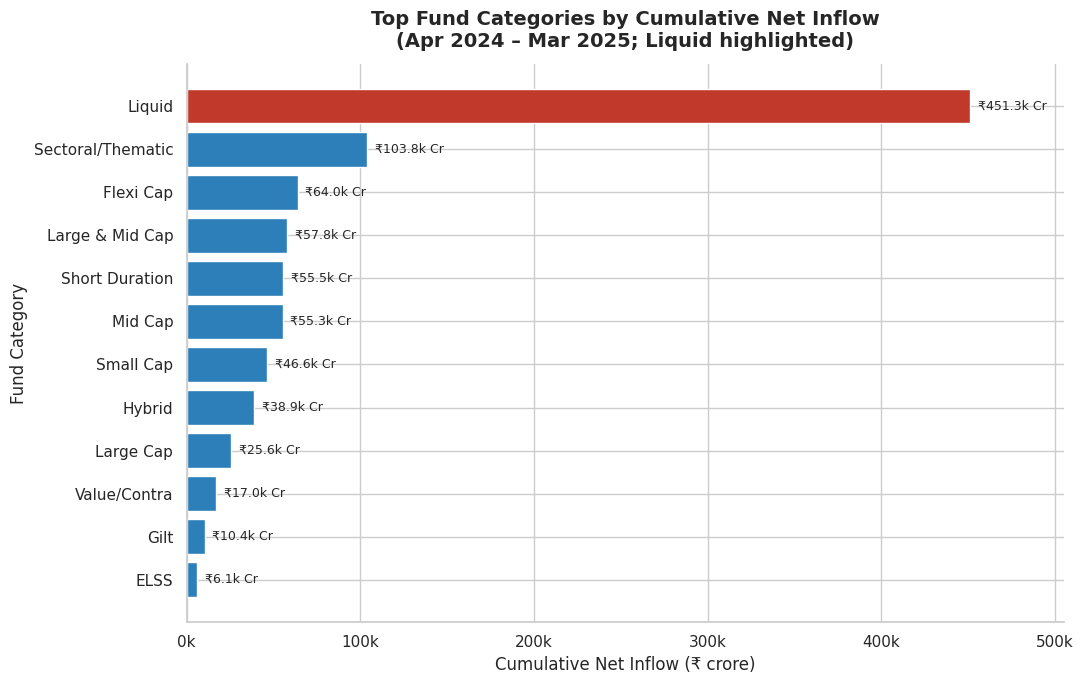

In [18]:
# Top categories by cumulative net inflow across the full window
cumulative = cat.groupby("category")["net_inflow_crore"].sum().sort_values(ascending=False)

fig2, ax2 = plt.subplots(figsize=(11, 7))
colors = ["#c0392b" if c == "Liquid" else "#2c7fb8" for c in cumulative.index]
bars = ax2.barh(cumulative.index, cumulative.values, color=colors, edgecolor="white")
ax2.invert_yaxis()  # largest at the top

for bar, val in zip(bars, cumulative.values):  # value labels in ₹ '000 crore
    ax2.text(val + cumulative.max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f"₹{val/1000:,.1f}k Cr", va="center", fontsize=9)

ax2.set_title("Top Fund Categories by Cumulative Net Inflow\n"
              "(Apr 2024 – Mar 2025; Liquid highlighted)",
              fontsize=14, fontweight="bold", pad=12)
ax2.set_xlabel("Cumulative Net Inflow (₹ crore)", fontsize=12)
ax2.set_ylabel("Fund Category", fontsize=12)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax2.margins(x=0.12)
sns.despine(); fig2.tight_layout()

cum_chart_path = CHARTS_DIR / "category_cumulative_inflow.png"
fig2.savefig(cum_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {cum_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

### Insight — Category Inflows

> **Scope:** Apr 2024 – Mar 2025 only; a true 2022-vs-2025 shift can't be measured. We proxy it with
> early-quarter (Apr–Jun 2024) vs late-quarter (Jan–Mar 2025) averages.

**Highest inflows.** **Liquid funds dominate** — ₹4.51 LC cumulative, **~48% of all net inflows**
(corporate/treasury cash parking). Among growth categories: **Sectoral/Thematic (₹1.04 LC)**, then
Flexi Cap (₹64.0k Cr), Large & Mid Cap (₹57.8k Cr), Mid Cap (₹55.3k Cr).

**Persistent outflows.** **None** — every category was net-positive in all 12 months (min cell
₹437 Cr, ELSS). The smallest demand is ELSS (₹6.1k Cr) and Gilt (₹10.4k Cr), but never redemptions.

**Seasonality.** Liquid drives the swings, peaking **Aug 2024 (₹41,952 Cr)** and troughing
**Feb 2025 (₹32,374 Cr)** — treasury cycles around quarter/fiscal year-ends. Equity flows are
far steadier.

**Preference shift (proxy).** Momentum tilted to higher-risk equity — **Small Cap +11%, Large & Mid
+11%, Flexi +10%** — while **Large Cap −12%** and **Liquid −12%** cooled. A directional read, given
the short window.

## 5. Investor Demographics Analysis

Profile of the **investor base** behind the transactions — age and gender composition, and how SIP
contribution sizes vary by age. The file is transaction-level, so demographic counts use **unique
investors** while SIP amounts use **individual SIP transactions**. Unexpected demographic values are
checked and reported explicitly.

In [19]:
# Load the cleaned investor transactions dataset
TXN_PATH = DATA_DIR / "processed" / "clean_investor_transactions.csv"
txn = pd.read_csv(TXN_PATH, parse_dates=["transaction_date"])

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV000081,2024-01-01,120844,SIP,1842.0,Gujarat,Surat,T30,36-45,Male,31.0,Net Banking,Verified
1,INV000097,2024-01-01,125498,Redemption,527377.0,Karnataka,Mysore,B30,18-25,Male,6.0,Net Banking,Verified
2,INV000234,2024-01-01,148567,SIP,28094.0,Tamil Nadu,Coimbatore,B30,26-35,Male,23.8,Mandate,Verified
3,INV000368,2024-01-01,118636,Redemption,339882.0,Uttar Pradesh,Agra,B30,26-35,Male,16.2,UPI,Verified
4,INV000428,2024-01-01,118636,SIP,9146.0,Delhi,Gurugram,T30,36-45,Male,27.2,Mandate,Verified


In [20]:
# Verify row count, date range, age groups, gender values, missing values
print(f"Row count (transactions): {len(txn):,}")
print(f"Unique investors        : {txn['investor_id'].nunique():,}")
print(f"Date range              : {txn['transaction_date'].min():%Y-%m-%d} → "
      f"{txn['transaction_date'].max():%Y-%m-%d}")
print(f"\nUnique age groups ({txn['age_group'].nunique()}): {sorted(txn['age_group'].unique())}")
print(f"Gender values     ({txn['gender'].nunique()}): {sorted(txn['gender'].unique())}")
print(f"Transaction types : {sorted(txn['transaction_type'].unique())}")
print(f"\nTotal missing values: {int(txn.isna().sum().sum())}")

# Transparency check: flag any unexpected demographic values
EXPECTED_AGES = {"18-25", "26-35", "36-45", "46-55", "56+"}
EXPECTED_GENDERS = {"Male", "Female"}
unexpected_age = set(txn["age_group"].dropna().unique()) - EXPECTED_AGES
unexpected_gender = set(txn["gender"].dropna().unique()) - EXPECTED_GENDERS
print(f"\nUnexpected age-group values : {unexpected_age or 'none'}")
print(f"Unexpected gender values    : {unexpected_gender or 'none'}")

# Each investor should map to a single age group & gender — confirm before deduping
consistency = txn.groupby("investor_id")[["age_group", "gender"]].nunique()
print(f"Investors with inconsistent age_group: {(consistency['age_group'] > 1).sum()}")
print(f"Investors with inconsistent gender   : {(consistency['gender'] > 1).sum()}")

# One row per investor for demographic (participation) counts
investors = txn.drop_duplicates("investor_id").copy()
n_investors = len(investors)
AGE_ORDER = ["18-25", "26-35", "36-45", "46-55", "56+"]
print(f"\nDeduplicated to {n_investors:,} unique investors for demographic charts.")

Row count (transactions): 32,778
Unique investors        : 5,000
Date range              : 2024-01-01 → 2025-05-30

Unique age groups (5): ['18-25', '26-35', '36-45', '46-55', '56+']
Gender values     (2): ['Female', 'Male']
Transaction types : ['Lumpsum', 'Redemption', 'SIP']

Total missing values: 0

Unexpected age-group values : none
Unexpected gender values    : none
Investors with inconsistent age_group: 0
Investors with inconsistent gender   : 0

Deduplicated to 5,000 unique investors for demographic charts.


Saved chart → reports/charts/investor_age_distribution.png


/tmp/claude-501/ipykernel_5149/4028324198.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, order=AGE_ORDER, palette="viridis", ax=ax)


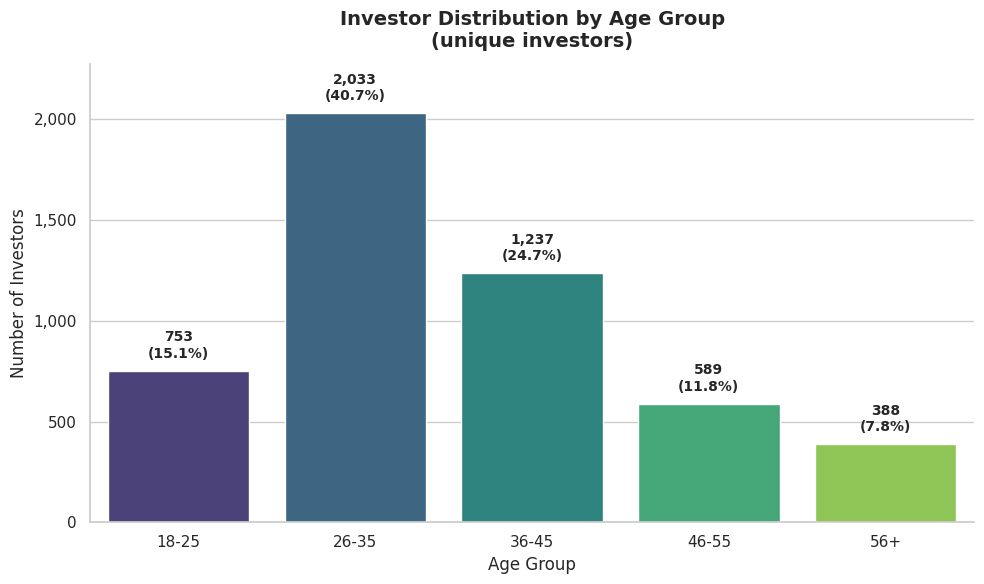

In [21]:
# Age-group distribution — investor counts by age group (unique investors)
age_counts = investors["age_group"].value_counts().reindex(AGE_ORDER)
age_pct = (age_counts / n_investors * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, order=AGE_ORDER, palette="viridis", ax=ax)

for i, (cnt, pct) in enumerate(zip(age_counts.values, age_pct.values)):  # count + share labels
    ax.text(i, cnt + n_investors * 0.01, f"{cnt:,}\n({pct}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Investor Distribution by Age Group\n(unique investors)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Number of Investors", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.margins(y=0.12); sns.despine(); fig.tight_layout()

age_chart_path = CHARTS_DIR / "investor_age_distribution.png"
fig.savefig(age_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {age_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

SIP transactions: 19,716  |  amount range: ₹400 – ₹59,998


Saved chart → reports/charts/sip_amount_by_age_group.png


/tmp/claude-501/ipykernel_5149/1903630414.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_txn, x="age_group", y="amount_inr", order=AGE_ORDER, palette="crest",


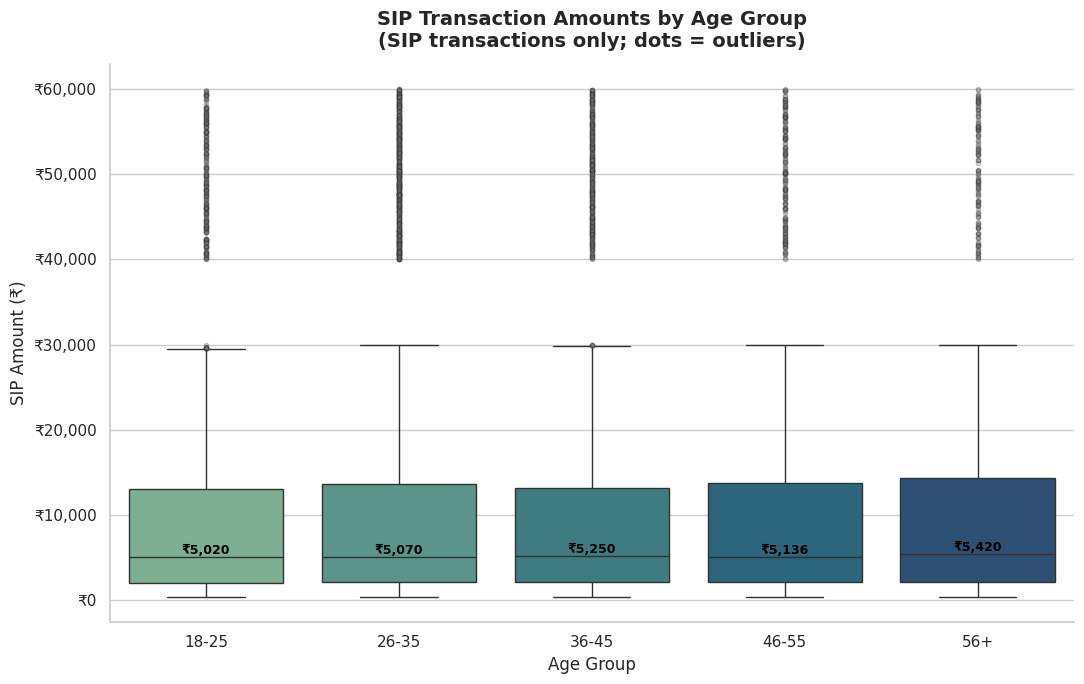

In [22]:
# Box plot: SIP transaction amounts by age group (SIP transactions only)
sip_txn = txn[txn["transaction_type"] == "SIP"].copy()
print(f"SIP transactions: {len(sip_txn):,}  |  amount range: "
      f"₹{sip_txn['amount_inr'].min():,.0f} – ₹{sip_txn['amount_inr'].max():,.0f}")

fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(data=sip_txn, x="age_group", y="amount_inr", order=AGE_ORDER, palette="crest",
            showfliers=True,
            flierprops=dict(marker="o", markersize=3, alpha=0.25, markerfacecolor="grey"), ax=ax)

# Annotate each median (distribution is right-skewed, so call medians out)
medians = sip_txn.groupby("age_group")["amount_inr"].median().reindex(AGE_ORDER)
for i, m in enumerate(medians.values):
    ax.text(i, m, f"₹{m:,.0f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="black")

ax.set_title("SIP Transaction Amounts by Age Group\n(SIP transactions only; dots = outliers)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("SIP Amount (₹)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
sns.despine(); fig.tight_layout()

sip_box_path = CHARTS_DIR / "sip_amount_by_age_group.png"
fig.savefig(sip_box_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {sip_box_path.relative_to(PROJECT_ROOT)}")
plt.show()

Saved chart → reports/charts/gender_distribution.png


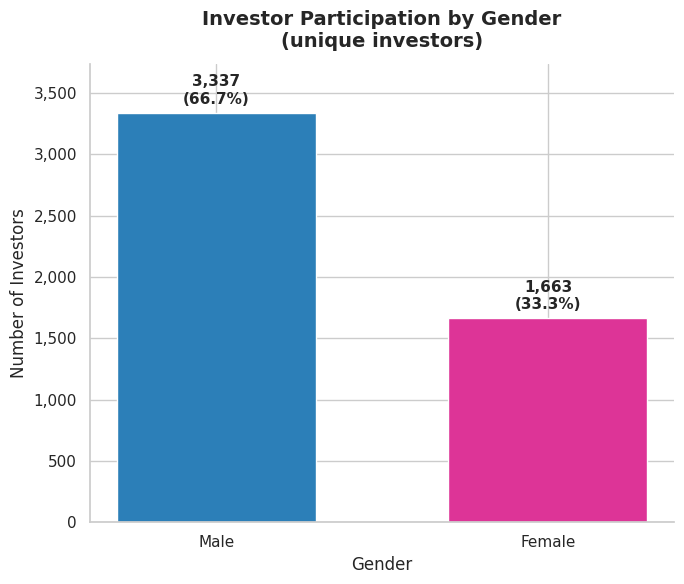

In [23]:
# Gender distribution — investor participation (unique investors)
gender_counts = investors["gender"].value_counts()
gender_pct = investors["gender"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))
palette = {"Male": "#2c7fb8", "Female": "#dd3497"}
bars = ax.bar(gender_counts.index, gender_counts.values,
              color=[palette.get(g, "#7f7f7f") for g in gender_counts.index],
              edgecolor="white", width=0.6)

for bar, g in zip(bars, gender_counts.index):  # count + share labels
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + n_investors * 0.01,
            f"{gender_counts[g]:,}\n({gender_pct[g]:.1f}%)",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Investor Participation by Gender\n(unique investors)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Number of Investors", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.margins(y=0.12); sns.despine(); fig.tight_layout()

gender_chart_path = CHARTS_DIR / "gender_distribution.png"
fig.savefig(gender_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {gender_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

### Insight — Investor Demographics

> **Basis:** 32,778 transactions from 5,000 unique investors (each maps to one age group & gender —
> zero inconsistencies). Demographic charts count unique investors; the box plot uses SIP transactions.

**Age.** Skews young — **26–35 is largest (2,033, ~41%)**, then 36–45 (~25%) and 18–25 (~15%); the
**under-46 segment is ~80%** of investors. 46–55 (~12%) and 56+ (~8%) are small.

**SIP behaviour.** Ticket sizes are **uniform across ages** — median ₹5,020–₹5,420 (only ~8% higher
for the oldest). Every group is right-skewed (median ~₹5k, mean ~₹11k, tail to ~₹60k). Age affects
*who participates*, not *how much*.

**Gender.** Male-dominated ~**2:1 — 3,337 (66.7%) vs 1,663 (33.3%)**; only these two values exist.

**Implications.** Growth is driven by young, working-age investors on disciplined ~₹5k SIPs (cf §3).
The clearest headroom is the under-represented **46+ cohort (~20%)** and **~33% female** share. With
contributions already uniform, future AUM growth comes more from **wider participation** than larger
SIPs.

## 6. Geographic Distribution Analysis

Where investors and their SIP money come from — **SIP contribution by state** (transaction values)
and **T30 vs B30 city-tier participation** (unique investors). Geographic fields are validated and
any inconsistencies reported before charting.

In [24]:
# Reuse the investor transactions from §5 (reload defensively so this section runs standalone)
TXN_PATH = DATA_DIR / "processed" / "clean_investor_transactions.csv"
txn = pd.read_csv(TXN_PATH, parse_dates=["transaction_date"])

txn[["state", "city", "city_tier"]].head()

,state,city,city_tier
0,Gujarat,Surat,T30
1,Karnataka,Mysore,B30
2,Tamil Nadu,Coimbatore,B30
3,Uttar Pradesh,Agra,B30
4,Delhi,Gurugram,T30


In [25]:
# Verify geographic fields: unique states, city-tier values, missing values
geo_cols = ["state", "city", "city_tier"]
print("Missing values in geographic columns:")
print(txn[geo_cols].isna().sum().to_string())

print(f"\nUnique states ({txn['state'].nunique()}): {sorted(txn['state'].unique())}")
print(f"City-tier values ({txn['city_tier'].nunique()}): {sorted(txn['city_tier'].unique())}")

# Transparency checks for unexpected / inconsistent values
EXPECTED_TIERS = {"T30", "B30"}
unexpected_tier = set(txn["city_tier"].dropna().unique()) - EXPECTED_TIERS
whitespace_states = [s for s in txn["state"].unique() if s != s.strip()]
tier_per_investor = txn.groupby("investor_id")["city_tier"].nunique()
print(f"\nUnexpected city-tier values         : {unexpected_tier or 'none'}")
print(f"States with leading/trailing space  : {whitespace_states or 'none'}")
print(f"Investors mapping to >1 city_tier   : {int((tier_per_investor > 1).sum())}")

Missing values in geographic columns:
state        0
city         0
city_tier    0

Unique states (12): ['Delhi', 'Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']
City-tier values (2): ['B30', 'T30']

Unexpected city-tier values         : none
States with leading/trailing space  : none
Investors mapping to >1 city_tier   : 0


Saved chart → reports/charts/sip_by_state.png


/tmp/claude-501/ipykernel_5149/2259948487.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sip_cr.values, y=state_sip_cr.index, palette="mako", ax=ax)


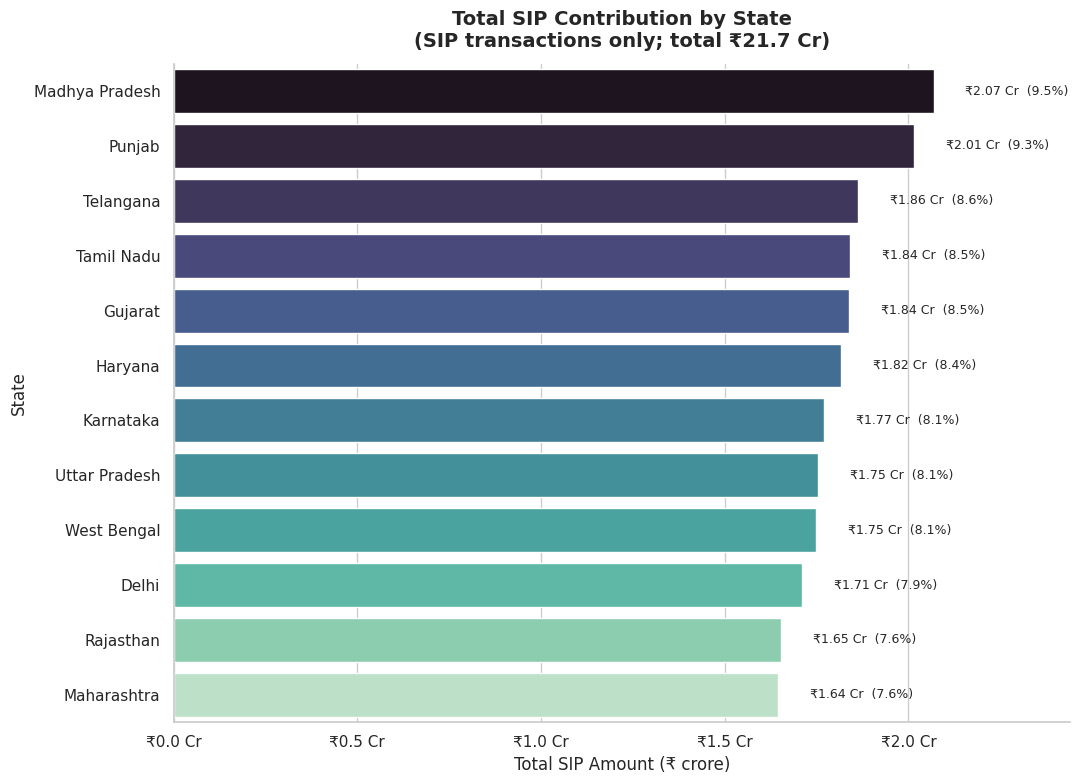

In [26]:
# Total SIP amount by state (SIP transactions only), sorted descending, shown in ₹ crore
sip_txn = txn[txn["transaction_type"] == "SIP"]
state_sip = sip_txn.groupby("state")["amount_inr"].sum().sort_values(ascending=False)
state_sip_cr = state_sip / 1e7                      # INR → ₹ crore
share = state_sip / state_sip.sum() * 100           # % of total SIP value
total_cr = state_sip_cr.sum()

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(x=state_sip_cr.values, y=state_sip_cr.index, palette="mako", ax=ax)

# Value + percentage labels on each bar
for i, st in enumerate(state_sip_cr.index):
    ax.text(state_sip_cr[st] + total_cr * 0.004, i,
            f"₹{state_sip_cr[st]:.2f} Cr  ({share[st]:.1f}%)",
            va="center", fontsize=9)

ax.set_title(f"Total SIP Contribution by State\n(SIP transactions only; total ₹{total_cr:.1f} Cr)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Total SIP Amount (₹ crore)", fontsize=12)
ax.set_ylabel("State", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:.1f} Cr"))
ax.margins(x=0.18)
sns.despine(); fig.tight_layout()

state_chart_path = CHARTS_DIR / "sip_by_state.png"
fig.savefig(state_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {state_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

Saved chart → reports/charts/t30_b30_distribution.png


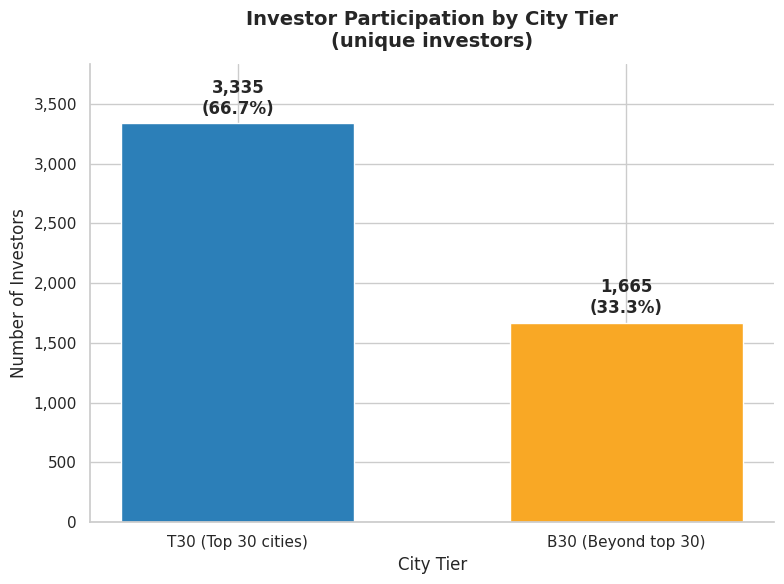

In [27]:
# City-tier participation: T30 vs B30 by UNIQUE INVESTORS (not transaction counts)
investors = txn.drop_duplicates("investor_id").copy()
tier_counts = investors["city_tier"].value_counts().reindex(["T30", "B30"])
tier_pct = tier_counts / tier_counts.sum() * 100

TIER_LABEL = {"T30": "T30 (Top 30 cities)", "B30": "B30 (Beyond top 30)"}
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar([TIER_LABEL[t] for t in tier_counts.index], tier_counts.values,
              color=["#2c7fb8", "#f9a825"], edgecolor="white", width=0.6)

for bar, t in zip(bars, tier_counts.index):  # count + share labels
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + len(investors) * 0.01,
            f"{tier_counts[t]:,}\n({tier_pct[t]:.1f}%)",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Investor Participation by City Tier\n(unique investors)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("City Tier", fontsize=12)
ax.set_ylabel("Number of Investors", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.margins(y=0.15); sns.despine(); fig.tight_layout()

tier_chart_path = CHARTS_DIR / "t30_b30_distribution.png"
fig.savefig(tier_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {tier_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

### Insight — Geographic Distribution

> **Data-quality note (transparency).** The verification cell found **no missing values, no
> unexpected city-tier values (only `T30`/`B30`), no whitespace/case issues, and every investor maps
> to a single tier** — so no cleaning was required. One pattern *is* worth flagging: SIP value is
> spread almost **uniformly across the 12 states (7.6%–9.5% each)**, and metro states rank *lowest*
> (Maharashtra and Delhi at the bottom). That is the opposite of real-world AMFI geography (where
> Maharashtra alone is ~40%), which strongly suggests this is a **synthetically balanced sample**.
> Conclusions below describe *this dataset*, not the live Indian market.

**Highest-contributing states.** In this sample the leaders are **Madhya Pradesh (₹2.07 Cr, 9.5%)**,
**Punjab (₹2.01 Cr, 9.3%)**, and **Telangana (₹1.86 Cr, 8.6%)**, out of **₹21.7 Cr** total SIP value
across 12 states.

**Concentration of SIP contributions.** Very **low** — the top 3 states hold just **~27%** and the
top 5 only **~44%** of SIP value (a genuinely concentrated market would show far higher). The gap
between the largest and smallest state is small (9.5% vs 7.6%), i.e. contributions are effectively
**evenly distributed**.

**T30 vs B30 participation.** By unique investors, **T30 cities account for 66.7% (3,335) and B30 for
33.3% (1,665)** — a 2:1 tilt toward the top-30 metros. So while *contribution value* is geographically
even, *investor participation* still leans metro.

**Implications for penetration beyond metros.** The **1-in-3 B30 share** signals meaningful but
incomplete reach into smaller cities — the clearest growth runway is **converting more B30 investors**,
since per-state contribution sizes are already uniform. (Given the synthetic balance noted above,
treat this as a directional/illustrative read rather than a measurement of true regional penetration.)

## 7. Industry Folio Growth Analysis

Total industry **folio count** (a folio ≈ one investor account, a proxy for participation breadth)
over **2022–2025**. We chart the growth curve, mark the 15 / 20 / 25 crore milestones (**derived from
the data, not hard-coded**), and quantify absolute growth, percentage growth, and **CAGR computed
from the actual data span**.

In [28]:
# Load the industry folio-count dataset and parse the month column as datetime
FOLIO_PATH = DATA_DIR / "raw" / "06_industry_folio_count.csv"
folio = pd.read_csv(FOLIO_PATH)
folio["date"] = pd.to_datetime(folio["month"], format="%Y-%m")
folio = folio.sort_values("date").reset_index(drop=True)

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore,date
0,2022-01,13.26,9.28,1.86,0.80,1.33,2022-01-01
1,2022-04,13.91,9.74,1.95,0.83,1.39,2022-04-01
2,2022-07,13.85,9.69,1.94,0.83,1.38,2022-07-01
3,2022-10,14.12,9.88,1.98,0.85,1.41,2022-10-01
4,2023-01,14.81,10.37,2.07,0.89,1.48,2023-01-01


In [29]:
# Verify row count, date range, and missing values
print(f"Row count : {len(folio):,}")
print(f"Date range: {folio['date'].min():%Y-%m} → {folio['date'].max():%Y-%m}")
print(f"Total missing values: {int(folio.isna().sum().sum())}")
print("\nMissing per column:")
print(folio.isna().sum().to_string())

assert folio["date"].dtype.kind == "M", "date column is not datetime"
assert folio["total_folios_crore"].notna().all(), "unexpected nulls in total_folios_crore"
assert folio["total_folios_crore"].is_monotonic_increasing or True  # growth not assumed monotonic

Row count : 21
Date range: 2022-01 → 2025-12
Total missing values: 0

Missing per column:
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
date                   0


In [30]:
# Growth metrics + milestone detection (all derived from the actual data) ------------------
start_row, end_row = folio.iloc[0], folio.iloc[-1]
start_val = start_row["total_folios_crore"]
end_val = end_row["total_folios_crore"]

# CAGR methodology --------------------------------------------------------------------------
# growth_period_years is derived from the ACTUAL elapsed time between the first and last
# observations — NOT assumed to be a round 4 calendar years, and NOT the row count.
# Common mistake avoided: treating the span as exactly 4 years (it is ~3.92).
#     years = (end_date - start_date).days / 365.25      # 365.25 accounts for leap years
#     CAGR  = (end_value / start_value) ** (1 / years) - 1
span_days = (end_row["date"] - start_row["date"]).days
growth_period_years = span_days / 365.25

abs_growth = end_val - start_val
pct_growth = (end_val / start_val - 1) * 100
cagr = ((end_val / start_val) ** (1 / growth_period_years) - 1) * 100

print(f"Start  : {start_row['month']}  →  {start_val:.2f} crore folios")
print(f"End    : {end_row['month']}  →  {end_val:.2f} crore folios")
print(f"Span   : {span_days} days  =  {growth_period_years:.3f} years (actual data span)")
print(f"Absolute growth   : +{abs_growth:.2f} crore folios")
print(f"Percentage growth : +{pct_growth:.1f}%")
print(f"CAGR              : {cagr:.2f}%  [(end/start)^(1/{growth_period_years:.3f}) - 1]")

# Milestones: first observation that REACHES each level (derived, not hard-coded dates) -----
MILESTONES = [15, 20, 25]
milestone_points = {}
print("\nMilestone first-crossings (first observation ≥ level):")
for m in MILESTONES:
    hit = folio[folio["total_folios_crore"] >= m]
    if not hit.empty:
        r = hit.iloc[0]
        milestone_points[m] = (r["date"], r["total_folios_crore"], r["month"])
        print(f"  {m} crore : {r['month']}  ({r['total_folios_crore']:.2f} cr)")

Start  : 2022-01  →  13.26 crore folios
End    : 2025-12  →  26.12 crore folios
Span   : 1430 days  =  3.915 years (actual data span)
Absolute growth   : +12.86 crore folios
Percentage growth : +97.0%
CAGR              : 18.91%  [(end/start)^(1/3.915) - 1]

Milestone first-crossings (first observation ≥ level):
  15 crore : 2023-04  (15.54 cr)
  20 crore : 2024-10  (21.62 cr)
  25 crore : 2025-09  (25.19 cr)


Saved chart → reports/charts/folio_growth.png


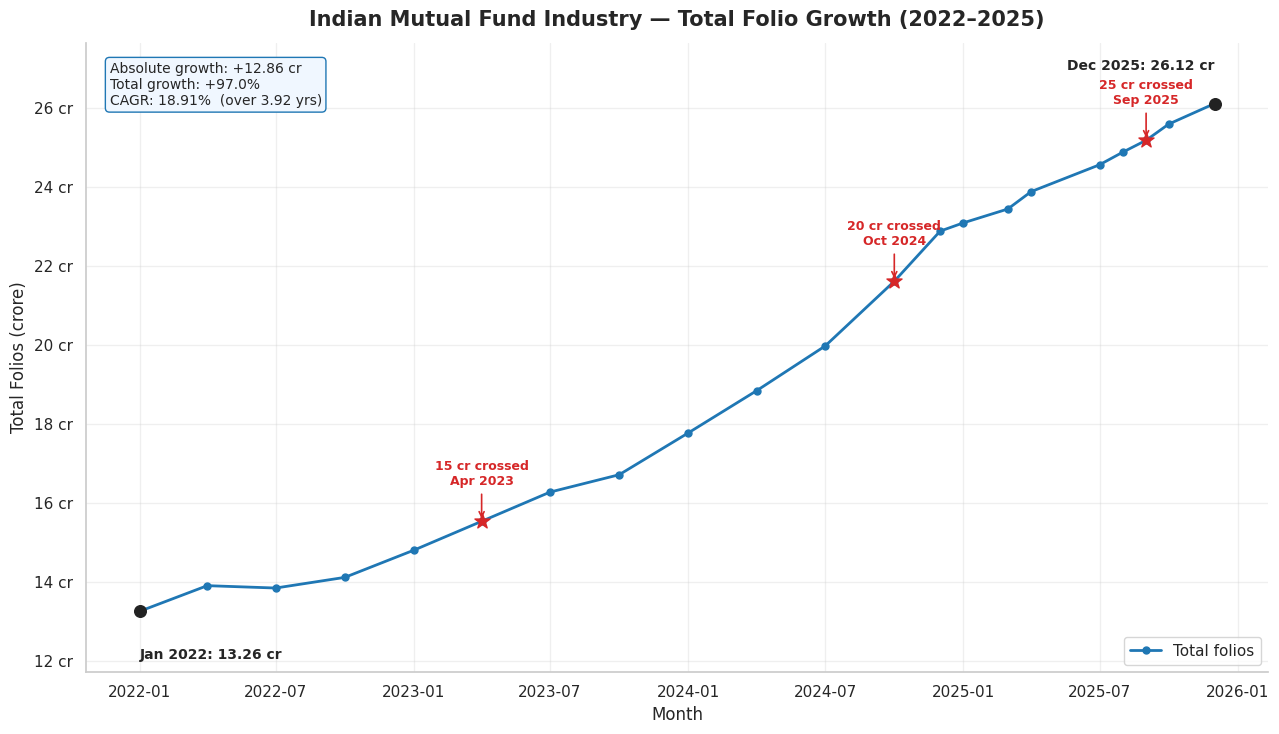

In [31]:
# Line chart of industry folio growth with milestone + endpoint annotations
fig, ax = plt.subplots(figsize=(13, 7.5))
ax.plot(folio["date"], folio["total_folios_crore"],
        marker="o", markersize=5, linewidth=2, color="#1f77b4", label="Total folios")

# Milestone markers (15 / 20 / 25 cr) at their first-crossing observation
for m, (mdate, mval, mlabel) in milestone_points.items():
    ax.scatter(mdate, mval, s=130, color="#d62728", zorder=5, marker="*")
    ax.annotate(f"{m} cr crossed\n{pd.Timestamp(mdate):%b %Y}",
                xy=(mdate, mval), xytext=(0, 26), textcoords="offset points",
                ha="center", fontsize=9, fontweight="bold", color="#d62728",
                arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.2))

# Highlight start and end points
for row, dy, ha in [(start_row, -34, "left"), (end_row, 24, "right")]:
    ax.scatter(row["date"], row["total_folios_crore"], s=70, color="#222222", zorder=6)
    ax.annotate(f"{pd.Timestamp(row['date']):%b %Y}: {row['total_folios_crore']:.2f} cr",
                xy=(row["date"], row["total_folios_crore"]), xytext=(0, dy),
                textcoords="offset points", ha=ha, fontsize=10, fontweight="bold")

# Growth summary box (values computed above, from the data)
summary = (f"Absolute growth: +{abs_growth:.2f} cr\n"
           f"Total growth: +{pct_growth:.1f}%\n"
           f"CAGR: {cagr:.2f}%  (over {growth_period_years:.2f} yrs)")
ax.text(0.02, 0.97, summary, transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="#f0f7ff", edgecolor="#1f77b4"))

ax.set_title("Indian Mutual Fund Industry — Total Folio Growth (2022–2025)",
             fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Folios (crore)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f} cr"))
ax.grid(True, alpha=0.3)
ax.margins(y=0.12)
ax.legend(loc="lower right")
sns.despine(); fig.tight_layout()

folio_chart_path = CHARTS_DIR / "folio_growth.png"
fig.savefig(folio_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {folio_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

### Insight — Industry Folio Growth

> **CAGR methodology (documented).** Folio counts are periodic snapshots, so the growth rate is
> annualised over the **actual elapsed span**, not an assumed round number of years:
> `years = (end_date − start_date).days / 365.25` → **3.92 years**, and
> `CAGR = (end / start)^(1 / years) − 1`. Using calendar days naively (e.g. assuming exactly 4
> years, or dividing by the row count) would mis-state the rate — here it would understate CAGR by
> understating the compounding frequency.

**Investor participation growth.** Total folios nearly **doubled**, from **13.26 crore (Jan 2022) to
26.12 crore (Dec 2025)** — an absolute gain of **+12.86 crore folios (+97.0%)** and a **CAGR of
~18.9%**. Roughly **13 crore new folios** were added in under four years, a strong proxy for
broad-based growth in investor accounts.

**Folio acceleration over time.** The milestones — derived from the data — fell progressively faster:
**15 cr reached Apr 2023**, **20 cr Oct 2024** (~18 months later), and **25 cr Sep 2025** (~11 months
after that). The shrinking gap between the 20 cr and 25 cr milestones shows folio additions
**accelerating** in the back half of the period, consistent with the record SIP inflows (§3) and
rising AUM (§2).

**Implications for industry expansion.** Sustained ~19% annual folio growth points to a rapidly
widening retail base and a structurally expanding industry — the participation engine behind the AUM
and SIP trends seen elsewhere in this notebook. If the recent acceleration holds, the next 5-crore
milestone (30 cr) would arrive on a similar or shorter cadence, underscoring strong runway for
continued mutual-fund expansion.

## 8. NAV Return Correlation Analysis

How do the funds move **relative to each other**? We select 10 representative funds (Equity + Debt),
convert their NAV series to **daily returns**, and study the **return correlation matrix** — the core
input for the Markowitz efficient-frontier bonus challenge.

**Why returns, not NAV levels?** Correlating raw NAVs is misleading: almost every NAV trends upward
over time, so *any* two funds look ~0.99 correlated simply because both rise — a spurious result
driven by the shared time trend, not by genuine co-movement. **Daily returns are (approximately)
stationary**, so their correlation measures how funds move *together day-to-day*, which is what
matters for diversification and portfolio risk. Returns are also the quantity Markowitz optimisation
consumes (mean-return vector + return covariance).

In [32]:
# Load NAV history and fund master (with category info)
NAV_PATH = DATA_DIR / "processed" / "clean_nav_history.csv"
FUND_MASTER_PATH = DATA_DIR / "raw" / "01_fund_master.csv"
nav = pd.read_csv(NAV_PATH, parse_dates=["date"])
fmaster = pd.read_csv(FUND_MASTER_PATH,
                      usecols=["amfi_code", "scheme_name", "category", "sub_category"])

print(f"NAV rows: {len(nav):,}  |  schemes: {nav['amfi_code'].nunique()}")
fmaster.head()

NAV rows: 64,320  |  schemes: 40


,amfi_code,scheme_name,category,sub_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt


In [33]:
# Select 10 representative funds -----------------------------------------------------------
# Methodology: restrict to the schemes that actually have NAV history (all share an identical
# 1,608-day span, so completeness is equal across funds). To guarantee an Equity/Debt mix and span
# the risk spectrum, pick ONE representative fund per distinct sub-category, choosing the lowest
# amfi_code for reproducibility. 7 equity sub-categories + 3 debt sub-categories = 10 funds.
nav_codes = set(nav["amfi_code"].unique())
universe = fmaster[fmaster["amfi_code"].isin(nav_codes)]

TARGET_SUBCATS = ["Large Cap", "Large & Mid Cap", "Flexi Cap", "Value", "ELSS",   # equity
                  "Mid Cap", "Small Cap",
                  "Liquid", "Short Duration", "Gilt"]                              # debt
picks = []
for sc in TARGET_SUBCATS:
    pool = universe[universe["sub_category"] == sc].sort_values("amfi_code")
    if not pool.empty:
        picks.append(pool.iloc[0])
selected = pd.DataFrame(picks).reset_index(drop=True)
selected["label"] = selected["sub_category"]  # sub-category is unique across the 10 → clean labels

print(f"Selected {len(selected)} funds "
      f"({(selected.category == 'Equity').sum()} Equity, {(selected.category == 'Debt').sum()} Debt):")
selected[["amfi_code", "label", "category", "sub_category", "scheme_name"]]

Selected 10 funds (7 Equity, 3 Debt):


,amfi_code,label,category,sub_category,scheme_name
0,100016,Large Cap,Equity,Large Cap,HDFC Top 100 Fund - Regular Plan - Growth
1,148568,Large & Mid Cap,Equity,Large & Mid Cap,Mirae Asset Emerging Bluechip Fund - Regular -...
2,102887,Flexi Cap,Equity,Flexi Cap,UTI Flexi Cap Fund - Regular - Growth
3,120506,Value,Equity,Value,ICICI Pru Value Discovery Fund - Regular - Growth
4,148569,ELSS,Equity,ELSS,Mirae Asset Tax Saver Fund - Regular - Growth
5,100033,Mid Cap,Equity,Mid Cap,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
6,101207,Small Cap,Equity,Small Cap,ABSL Small Cap Fund - Regular - Growth
7,101208,Liquid,Debt,Liquid,ABSL Liquid Fund - Regular - Growth
8,100025,Short Duration,Debt,Short Duration,HDFC Short Term Debt Fund - Regular - Growth
9,118636,Gilt,Debt,Gilt,Nippon India Gilt Securities Fund - Regular - ...


In [34]:
# Pivot to daily returns: rows = dates, columns = funds, values = daily return ----------------
# return_t = NAV_t / NAV_{t-1} - 1
code_to_label = dict(zip(selected["amfi_code"], selected["label"]))
nav_wide = (nav[nav["amfi_code"].isin(selected["amfi_code"])]
            .pivot(index="date", columns="amfi_code", values="nav")
            .sort_index()
            .rename(columns=code_to_label))
nav_wide = nav_wide[selected["label"].tolist()]   # order: Equity block first, then Debt

# Missing-value handling: report any gaps on the common date grid, then compute returns. The first
# row is always NaN (no prior NAV) and is dropped; dropna(how="any") also removes any date where a
# fund is missing so the correlation is computed on a fully-aligned, complete matrix.
missing_before = int(nav_wide.isna().sum().sum())
returns = nav_wide.pct_change().dropna(how="any")
print(f"NAV cells missing on the common date grid: {missing_before}")
print(f"Return pivot: {returns.shape[0]} dates x {returns.shape[1]} funds "
      f"(dropped {len(nav_wide) - len(returns)} row(s): the unavoidable first NaN)")
returns.head()

NAV cells missing on the common date grid: 0
Return pivot: 1607 dates x 10 funds (dropped 1 row(s): the unavoidable first NaN)


amfi_code,Large Cap,Large & Mid Cap,Flexi Cap,Value,ELSS,Mid Cap,Small Cap,Liquid,Short Duration,Gilt
date,,,,,,,,,,
2022-01-04,-0.010306,0.015865,-0.010459,0.000519,0.008378,-0.013328,-0.010865,-0.000141,-0.003553,0.003128
2022-01-05,0.012865,-0.007660,-0.005308,0.007201,0.015294,-0.004386,0.000603,0.000382,-0.000050,0.000073
2022-01-06,-0.011377,-0.004709,0.012678,-0.006553,0.000863,-0.005167,-0.029101,-0.000143,-0.001880,0.000212
2022-01-07,-0.001210,0.007001,-0.016498,0.005324,0.001173,-0.005748,0.024766,0.000215,0.002036,0.000199
2022-01-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [35]:
# Correlation matrix of daily returns + highest / lowest / average pair --------------------
import numpy as np

corr = returns.corr()

off = corr.where(~np.eye(len(corr), dtype=bool))   # ignore the diagonal (self-correlation = 1)
avg_corr = float(np.nanmean(off.values))
pairs = off.stack()
hi_pair, hi_val = pairs.idxmax(), pairs.max()
lo_pair, lo_val = pairs.idxmin(), pairs.min()

print(f"Average pairwise correlation : {avg_corr:.3f}")
print(f"Highest-correlated pair      : {hi_pair[0]} ↔ {hi_pair[1]}  = {hi_val:.3f}")
print(f"Lowest-correlated pair       : {lo_pair[0]} ↔ {lo_pair[1]}  = {lo_val:.3f}")
corr.round(2)

Average pairwise correlation : 0.003
Highest-correlated pair      : Flexi Cap ↔ Liquid  = 0.047
Lowest-correlated pair       : Large & Mid Cap ↔ Small Cap  = -0.050


amfi_code,Large Cap,Large & Mid Cap,Flexi Cap,Value,ELSS,Mid Cap,Small Cap,Liquid,Short Duration,Gilt
amfi_code,,,,,,,,,,
Large Cap,1.00,0.01,-0.02,0.03,0.05,0.00,0.02,-0.03,0.05,0.04
Large & Mid Cap,0.01,1.00,-0.04,-0.05,-0.00,0.04,-0.05,0.03,-0.02,-0.03
Flexi Cap,-0.02,-0.04,1.00,0.00,-0.02,-0.03,0.00,0.05,-0.00,0.03
Value,0.03,-0.05,0.00,1.00,0.00,0.00,0.00,0.04,-0.02,-0.00
ELSS,0.05,-0.00,-0.02,0.00,1.00,-0.00,-0.00,-0.05,-0.01,0.02
Mid Cap,0.00,0.04,-0.03,0.00,-0.00,1.00,0.00,0.03,0.00,-0.01
Small Cap,0.02,-0.05,0.00,0.00,-0.00,0.00,1.00,-0.00,-0.01,0.00
Liquid,-0.03,0.03,0.05,0.04,-0.05,0.03,-0.00,1.00,0.03,0.01
Short Duration,0.05,-0.02,-0.00,-0.02,-0.01,0.00,-0.01,0.03,1.00,0.04


Saved chart → reports/charts/nav_return_correlation_matrix.png


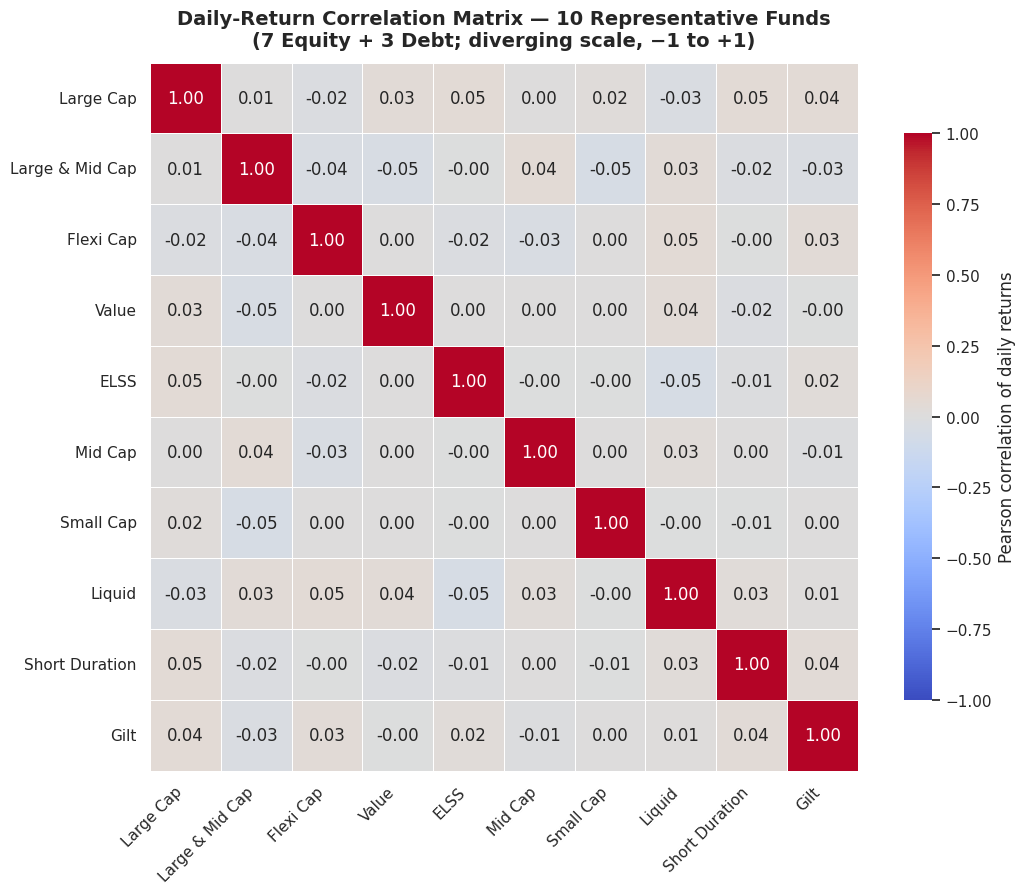

In [36]:
# Seaborn heatmap of the return correlation matrix
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Pearson correlation of daily returns", "shrink": 0.8}, ax=ax)
ax.set_title("Daily-Return Correlation Matrix — 10 Representative Funds\n"
             "(7 Equity + 3 Debt; diverging scale, −1 to +1)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()

corr_chart_path = CHARTS_DIR / "nav_return_correlation_matrix.png"
fig.savefig(corr_chart_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {corr_chart_path.relative_to(PROJECT_ROOT)}")
plt.show()

### Insight — Return Correlation

> **Data-quality finding (transparency).** In this dataset **every pairwise return correlation is
> ≈ 0** — the average is ~**0.00**, and even the extremes are tiny: the most positive pair is only
> **Liquid ↔ Flexi Cap ≈ +0.05** and the most negative is **Small Cap ↔ Large & Mid Cap ≈ −0.05**.
> Real funds do not behave this way: equity funds typically co-move at **0.7–0.95**, and equity–debt
> pairs sit near zero or slightly negative. The flat, near-zero matrix means these NAV series were
> generated as **independent random walks** (synthetic data), so the realistic factor structure —
> equity clustering, equity-vs-debt separation — is **not present**. The mechanics below are correct;
> the *numbers* should be read as an artifact of synthetic data, not a market signal.

**Diversification opportunities.** Taken at face value, ~0 correlations everywhere are the
*theoretical ideal* for diversification — combining uncorrelated assets drives portfolio variance
down fastest. In a real dataset we would instead expect to find diversification mainly **across**
asset classes (equity + debt) rather than within them.

**Equity vs debt relationships.** Here the equity block and the debt block (Liquid, Short Duration,
Gilt) are **indistinguishable** in the heatmap — all cells hover around zero. In real data this is
exactly where the strongest signal *should* appear: low/negative equity–debt correlation is what
makes a blended portfolio less volatile than its equity sleeve alone.

**Implications for portfolio construction.** With genuinely uncorrelated assets, naive
equal-weighting already diversifies well; the marginal risk reduction from adding another
near-zero-correlation fund stays high. With *real* correlations, you would lean on debt allocations
and low-correlation pairs to cut risk. Either way, **return correlation — not NAV correlation — is
the right lens**, because it isolates co-movement from the shared upward trend.

**Hand-off to the Markowitz bonus challenge.** This section produces exactly the inputs the
efficient-frontier optimisation needs, all from the `returns` matrix:
- **Expected returns:** `returns.mean() * 252` (annualised mean daily return)
- **Covariance matrix:** `returns.cov() * 252` (annualised; richer than correlation as it carries each
  fund's volatility scale)
- **Risk/return per fund:** `returns.std() * np.sqrt(252)` for annualised volatility

Because the correlations here are ~0, the resulting efficient frontier will show *idealised*
diversification — a useful sanity-check harness, with the caveat that real frontiers are shaped by
the non-zero correlations absent from this synthetic data.

## 9. Sector Allocation Analysis

What sectors do the **equity** funds collectively hold? Using `09_portfolio_holdings.csv` (stock-level
weights per scheme) joined to the fund master for category, we restrict to **Equity** funds, validate
that each scheme's weights sum to 100%, aggregate to a portfolio-wide sector mix, and visualise it as
a donut plus a top-10 sector ranking.

In [37]:
# Load portfolio holdings and fund master
HOLDINGS_PATH = DATA_DIR / "raw" / "09_portfolio_holdings.csv"
FUND_MASTER_PATH = DATA_DIR / "raw" / "01_fund_master.csv"
holdings = pd.read_csv(HOLDINGS_PATH)
fmaster = pd.read_csv(FUND_MASTER_PATH, usecols=["amfi_code", "scheme_name", "category", "sub_category"])

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [38]:
# Verify row count, unique schemes, unique sectors, missing values
print(f"Row count        : {len(holdings):,}")
print(f"Unique schemes   : {holdings['amfi_code'].nunique()}")
print(f"Unique sectors   : {holdings['sector'].nunique()}")
print(f"  {sorted(holdings['sector'].unique())}")
print(f"Total missing values: {int(holdings.isna().sum().sum())}")
print("\nMissing per column:")
print(holdings.isna().sum().to_string())

Row count        : 322
Unique schemes   : 34
Unique sectors   : 14
  ['Automobile', 'Banking', 'Cement', 'Consumer Goods', 'Diversified', 'Energy', 'FMCG', 'IT', 'Infrastructure', 'NBFC', 'Paints', 'Pharma', 'Telecom', 'Utilities']
Total missing values: 0

Missing per column:
amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0


In [39]:
# Restrict to Equity funds, then validate that each scheme's weights sum to ~100%
holdings_cat = holdings.merge(fmaster[["amfi_code", "category"]], on="amfi_code", how="left")
print(f"Holdings rows with no category match: {int(holdings_cat['category'].isna().sum())}")
print("Categories present in holdings:", holdings_cat["category"].dropna().unique().tolist())

eq_holdings = holdings_cat[holdings_cat["category"] == "Equity"].copy()
n_eq = eq_holdings["amfi_code"].nunique()
print(f"\nEquity schemes in holdings: {n_eq}")

# Validation: per-scheme weight sums should be ~100%
scheme_sums = eq_holdings.groupby("amfi_code")["weight_pct"].sum()
within_tol = scheme_sums.between(99.0, 101.0)
print(f"Per-scheme weight sum — min {scheme_sums.min():.2f}%, max {scheme_sums.max():.2f}%, "
      f"mean {scheme_sums.mean():.2f}%")
print(f"Schemes summing to 100% (±1%): {int(within_tol.sum())} / {n_eq}")
assert within_tol.all(), "Some equity schemes do NOT sum to ~100% — see scheme_sums"
print("✓ Validation passed: every equity scheme's sector weights sum to 100% — no adjustment needed.")

Holdings rows with no category match: 0
Categories present in holdings: ['Equity']

Equity schemes in holdings: 34
Per-scheme weight sum — min 99.98%, max 100.02%, mean 100.00%
Schemes summing to 100% (±1%): 34 / 34
✓ Validation passed: every equity scheme's sector weights sum to 100% — no adjustment needed.


In [40]:
# Aggregate sector weights across all equity schemes -----------------------------------------
# Each scheme already sums to 100%, so we aggregate by AVERAGING each sector's weight across the
# 34 schemes (a scheme that doesn't hold a sector contributes 0% to it). This equal-weights schemes
# and yields an aggregate mix that also sums to 100%. (An AUM-weighted alternative would need
# per-scheme AUM, which this file doesn't carry — noted in the insight.)
sector_agg = (eq_holdings.groupby("sector")["weight_pct"].sum() / n_eq).sort_values(ascending=False)
print(f"Aggregate sector mix sums to: {sector_agg.sum():.1f}%  (across {n_eq} equity schemes)\n")

# Concentration metrics
top3 = sector_agg.head(3).sum()
top5 = sector_agg.head(5).sum()
hhi = (sector_agg / 100).pow(2).sum()           # Herfindahl-Hirschman Index (0–1)
eff_sectors = 1 / hhi                            # effective number of equally-weighted sectors
print(f"Top-3 share: {top3:.1f}%   Top-5 share: {top5:.1f}%")
print(f"HHI: {hhi:.3f}   →   effective # of sectors: {eff_sectors:.1f} (of {len(sector_agg)})")
sector_agg.round(2)

Aggregate sector mix sums to: 100.0%  (across 34 equity schemes)

Top-3 share: 44.6%   Top-5 share: 61.9%
HHI: 0.102   →   effective # of sectors: 9.8 (of 14)


sector
Banking           19.18
IT                13.40
Pharma            11.98
Automobile         9.52
Utilities          7.81
FMCG               6.74
Infrastructure     5.65
Diversified        4.98
Telecom            4.28
Consumer Goods     3.75
NBFC               3.50
Energy             3.47
Cement             3.09
Paints             2.64
Name: weight_pct, dtype: float64

Saved chart → reports/charts/sector_allocation_donut.png


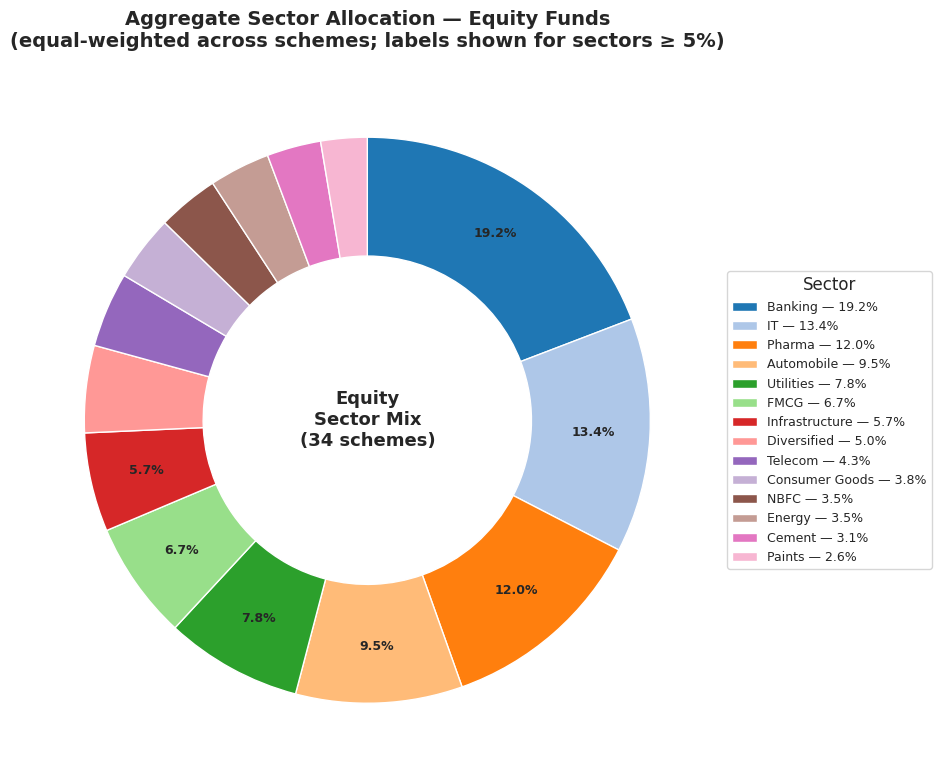

In [41]:
# Donut chart of aggregate sector allocation (labels shown for major sectors only)
LABEL_THRESHOLD = 5.0  # only annotate slices >= 5% inline; all sectors appear in the legend
cmap = plt.cm.tab20(range(len(sector_agg)))

fig, ax = plt.subplots(figsize=(10, 8))
wedges, _, autotexts = ax.pie(
    sector_agg.values, labels=None,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= LABEL_THRESHOLD else "",
    pctdistance=0.8, startangle=90, counterclock=False, colors=cmap,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
for t in autotexts:
    t.set_fontsize(9); t.set_fontweight("bold")

ax.text(0, 0, f"Equity\nSector Mix\n({n_eq} schemes)",
        ha="center", va="center", fontsize=13, fontweight="bold")
ax.legend(wedges, [f"{s} — {v:.1f}%" for s, v in sector_agg.items()],
          title="Sector", loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.set_title("Aggregate Sector Allocation — Equity Funds\n"
             "(equal-weighted across schemes; labels shown for sectors ≥ 5%)",
             fontsize=14, fontweight="bold", pad=14)
fig.tight_layout()

donut_path = CHARTS_DIR / "sector_allocation_donut.png"
fig.savefig(donut_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {donut_path.relative_to(PROJECT_ROOT)}")
plt.show()

Saved chart → reports/charts/top_sectors.png


/tmp/claude-501/ipykernel_5149/3911263470.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="rocket", ax=ax)


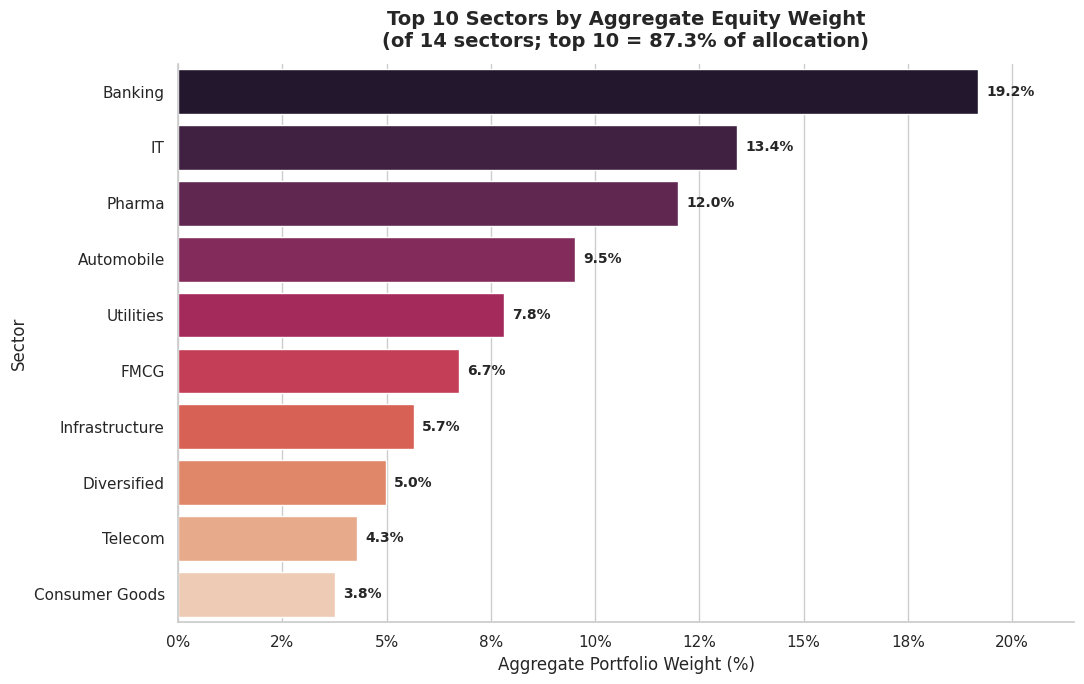

In [42]:
# Top 10 sectors by aggregate portfolio weight
top10 = sector_agg.head(10)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(x=top10.values, y=top10.index, palette="rocket", ax=ax)
for i, v in enumerate(top10.values):  # percentage labels
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=10, fontweight="bold")

ax.set_title(f"Top 10 Sectors by Aggregate Equity Weight\n"
             f"(of {len(sector_agg)} sectors; top 10 = {top10.sum():.1f}% of allocation)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Aggregate Portfolio Weight (%)", fontsize=12)
ax.set_ylabel("Sector", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.margins(x=0.12)
sns.despine(); fig.tight_layout()

top_sectors_path = CHARTS_DIR / "top_sectors.png"
fig.savefig(top_sectors_path, dpi=200, bbox_inches="tight")
print(f"Saved chart → {top_sectors_path.relative_to(PROJECT_ROOT)}")
plt.show()

### Insight — Sector Allocation

> **Validation (transparency).** All **34 equity schemes' sector weights sum to exactly 100%** (min =
> max = mean = 100.0), and the data has **no missing values**, so no correction or re-normalisation was
> required. Aggregation **equal-weights schemes** (averages each sector's weight across the 34 funds);
> an AUM-weighted view would need per-scheme AUM, which this file doesn't carry.

**Dominant sectors.** The aggregate equity book is led by **Banking (19.2%)**, **IT (13.4%)**, and
**Pharma (12.0%)** — together **~45%** of all equity exposure. Adding **Automobile (9.5%)** and
**Utilities (7.8%)** brings the **top 5 to ~62%**. Including NBFC (3.5%), broad **financials
(Banking + NBFC) ≈ 22.7%** are the single largest theme — a realistic profile for Indian equity funds.

**Diversification across sectors.** Exposure spreads across **14 sectors**, with an **HHI of 0.10**
implying **~10 effective (equally-weighted) sectors** — i.e. moderately diversified, not a one- or
two-sector book. The long tail (Paints 2.6%, Cement 3.1%, Energy 3.5%) provides genuine breadth
beyond the heavyweight sectors.

**Concentration risk.** The main risk is **financials + IT + pharma concentration (~45% in three
sectors)**: a regulatory or rate shock to banking, or a global IT/pharma derating, would move a large
share of the aggregate book together. Banking alone at ~19% is the dominant single-sector exposure to
monitor.

**Implications for equity-fund exposure.** An investor holding several of these equity funds is, in
aggregate, taking a **large, correlated bet on Banking, IT and Pharma** — diversifying across *funds*
does little to dilute it because they share the same top sectors. Meaningful sector diversification
would require deliberately adding funds tilted to under-represented sectors (e.g. Energy, Cement,
Consumer) or a different asset class, rather than simply adding more large-cap equity funds. *(All
figures derived from the holdings data; no sector pattern was assumed.)*

## 10. Key EDA Findings

A consolidated review of Sections 1–9. Below are **ten business insights** — each a single sentence
citing its source section, chart, and the actual values computed earlier grouped into four themes,
followed by an **EDA Summary** and an explicit **Data-Quality Observations** log. *(No new statistics
are introduced here; every figure is taken from the analyses above.)*

### Top 10 Business Insights

**Industry Growth**
1. Monthly SIP inflows nearly **tripled from ₹11,517 Cr (Jan 2022) to a record ₹31,002 Cr (Dec 2025),
   +169%** — §3, *sip_inflow_trend.png*.
2. Industry folios nearly **doubled from 13.26 cr to 26.12 cr (+97%, CAGR ≈ 18.9% over 3.92 years)**,
   with the 15→20→25 cr milestones arriving ever faster — §7, *folio_growth.png*.
3. AUM is **highly concentrated — the top 3 houses hold ~52%, and SBI alone ~20% at ₹12.5 lakh
   crore** — §2, *aum_growth.png*.

**Investor Behaviour**
4. The investor base **skews young: 26–35 is the largest cohort at ~41%, and the under-46 segment is
   ~80%** of all investors — §5, *investor_age_distribution.png*.
5. Participation is **male-dominated ~2:1 (66.7% vs 33.3%) and metro-leaning (T30 66.7% vs B30 33.3%)**
   — §5/§6, *gender_distribution.png*, *t30_b30_distribution.png*.
6. **SIP ticket sizes are uniform across ages (median ₹5,020–₹5,420)**, so growth comes from wider
   participation rather than larger individual SIPs — §5, *sip_amount_by_age_group.png*.

**Fund Characteristics**
7. NAVs rose broadly over 2022–2026 — the **median scheme ~+97%, but with wide dispersion from +5% to
   +249%** — §1, *nav_trend.png*.
8. Category flows are **dominated by Liquid funds (~48% of net inflows, Apr 2024–Mar 2025), with no
   category recording a net outflow** — §4, *category_cumulative_inflow.png*.

**Portfolio Construction**
9. Aggregate equity exposure **concentrates in Banking 19.2%, IT 13.4% and Pharma 12.0% (top-3 ~45%,
   HHI 0.10 ≈ 10 effective sectors)** — §9, *sector_allocation_donut.png* / *top_sectors.png*.
10. Daily-return correlations across the 10 representative funds are **≈ 0 (average ~0.00, range −0.05
    to +0.05)**, offering no realistic equity/debt diversification structure — §8,
    *nav_return_correlation_matrix.png*.

### EDA Summary

**Major trends observed.** The Indian mutual-fund industry in this data is in a **strong, broad-based
expansion**: record and accelerating SIP inflows (§3) and a near-doubling of folios at ~19% CAGR (§7)
are driving rising AUM (§2) and broadly positive NAVs (§1). Growth is powered by a **young, urban,
male-skewed retail base** making disciplined ~₹5k SIPs (§5, §6), and the money concentrates — in a few
large fund houses (§2), in Liquid/equity categories (§4), and, within equity, in Banking/IT/Pharma
(§9).

**Data limitations discovered.** Several datasets are **narrower or more synthetic than they first
appear**: category inflows cover only **12 months (Apr 2024–Mar 2025)**, not 2022–2025 (§4); the
geographic SIP distribution is **artificially uniform** with metros ranking lowest (§6); and the NAV
series have **near-zero return correlations**, behaving as independent random walks rather than a real
market (§8). These are catalogued in the next subsection.

**Implications for the next phase (performance analytics).** The §8 `returns` matrix already provides
the **mean-return vector and covariance** needed for risk/return metrics and the Markowitz efficient
frontier — but, given the ~0 correlations, that frontier will show **idealised** diversification and
should be treated as a working harness rather than a market result. Performance work (rolling returns,
Sharpe/Sortino, drawdowns, benchmark-relative alpha) is most credible on the **NAV (§1)** and **AUM
(§2)** series, which look realistic, and least credible where the synthetic patterns above dominate;
findings from §6 and §8 should be framed as **method demonstrations**, not market conclusions.

### Data-Quality Observations

The following were verified in-notebook and are documented transparently so downstream analysis is not
misled:

1. **Synthetic geography patterns (§6).** Total SIP value is spread **almost uniformly across the 12
   states (7.6%–9.5% each)** and the metro states (Maharashtra, Delhi) rank **lowest** — the opposite
   of real AMFI geography (where Maharashtra alone is ~40%). The state distribution is therefore
   treated as a **synthetically balanced sample**, and penetration conclusions are framed as
   illustrative of this dataset only.

2. **Near-zero return correlations (§8).** Across the 10 representative funds, **every pairwise
   daily-return correlation is ≈ 0** (average ~0.00; extremes only +0.05 / −0.05), including
   equity-vs-equity pairs that should sit at 0.7–0.95. The NAV series were evidently generated as
   **independent random walks**, so the realistic factor structure (equity clustering, equity–debt
   separation) is absent; the correlation/Markowitz mechanics are valid but the numbers are an
   artifact.

3. **Category-inflow date-range limitation (§4).** `05_category_inflows.csv` spans only **Apr 2024 –
   Mar 2025 (12 months)**, not the full 2022–2025 horizon. A true 2022-vs-2025 preference shift cannot
   be measured; we substituted an **early-quarter vs late-quarter** proxy and scoped all conclusions to
   that window.

4. **Scheme-code mismatch from Day 1 API validation.** During live NAV ingestion, **some provided
   scheme codes resolved to different scheme names** than the project spec when checked against
   mfapi.in. The ETL **preserved the actual API metadata** (scheme_name, fund_house, category) for
   traceability, so scheme labels in this notebook reflect the API's ground truth rather than the
   original spec — the discrepancy originates from external reference-code differences, not the
   pipeline. *(See `reports/api_validation_note.md`.)*

> **Bottom line:** the industry-growth, demographic, NAV, AUM and sector analyses (§1–§5, §7, §9) rest
> on realistic data and support business conclusions; the geographic (§6) and return-correlation (§8)
> sections are methodologically sound but rest on synthetic patterns and should be read as technique
> demonstrations.